# AR Lab Generation — Benchmark Statistics

Quantitative analysis of the formative lab-generation sweep: every registered model × prompt-specificity level (L1–L4) across three lab topics. This is the companion to the success/failure summary (`benchmark_summary`) — here we look at **what the successful runs actually produced**: tokens, cost, generation time, the structural shape of each generated lab, and how many **novel assets** (prefabs, textures, audio we don't yet have) each lab would require us to author.

The table covers **both successes and failures**. Cost/token/speed and structural sections aggregate the **successful** runs; a dedicated *Failed runs* section breaks down what the failures cost (some burned real tokens; others — bad model ids / config errors — never reached the model and carry no stats).

**Caveat on L1.** L1 prompts produce a rough `LabOutline`, not a full `Lab` — so modules/clips/objects/components are 0 for L1 by design. Structural sections below therefore restrict to **L3–L4**.

In [1]:
%matplotlib inline
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

# Full per-run table embedded inline — notebook is self-contained.
RECORDS = json.loads(r'''[{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:06:32.225048","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":917,"total_tokens":1691,"cost_usd":0.03138,"duration_ms":22755.309,"wall_s":22.76,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":40.2982881929,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:06:55.058269","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":798,"completion_tokens":1090,"total_tokens":1888,"cost_usd":0.03669,"duration_ms":22525.892,"wall_s":22.53,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":48.3887608091,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:07:28.219637","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":964,"total_tokens":1702,"cost_usd":0.03261,"duration_ms":32921.996,"wall_s":32.92,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":29.28133519,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:07:44.878662","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":750,"completion_tokens":876,"total_tokens":1626,"cost_usd":0.03003,"duration_ms":16422.139,"wall_s":16.42,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":53.3426248554,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:08:00.458443","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":902,"total_tokens":1632,"cost_usd":0.03071,"duration_ms":15337.643,"wall_s":15.34,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":58.8095576354,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:08:14.670099","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":918,"total_tokens":1692,"cost_usd":0.015705,"duration_ms":11336.723,"wall_s":11.34,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":80.9757810965,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:08:23.022601","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":798,"completion_tokens":818,"total_tokens":1616,"cost_usd":0.014265,"duration_ms":8053.957,"wall_s":8.05,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":101.5649822814,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:08:32.969536","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":891,"total_tokens":1629,"cost_usd":0.01521,"duration_ms":9705.756,"wall_s":9.71,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":91.8011950846,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:08:42.471458","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":750,"completion_tokens":917,"total_tokens":1667,"cost_usd":0.01563,"duration_ms":9265.044,"wall_s":9.27,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":98.974165692,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:08:51.656551","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":892,"total_tokens":1622,"cost_usd":0.015205,"duration_ms":8943.033,"wall_s":8.94,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":99.7424475567,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:09:01.226857","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":874,"total_tokens":1648,"cost_usd":0.0045135,"duration_ms":6623.455,"wall_s":6.62,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":131.955301274,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:09:06.962573","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":798,"completion_tokens":786,"total_tokens":1584,"cost_usd":0.0041355,"duration_ms":5432.132,"wall_s":5.43,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":144.6945692778,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:09:13.836176","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":872,"total_tokens":1610,"cost_usd":0.0044775,"duration_ms":6634.674,"wall_s":6.63,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":131.4307228961,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:09:19.363427","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":750,"completion_tokens":705,"total_tokens":1455,"cost_usd":0.003735,"duration_ms":5291.274,"wall_s":5.29,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":133.2382333631,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:09:25.336368","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":808,"total_tokens":1538,"cost_usd":0.0041835,"duration_ms":5736.584,"wall_s":5.74,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":140.8503736719,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:09:36.204764","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":1086,"total_tokens":1860,"cost_usd":0.0015123,"duration_ms":8083.165,"wall_s":8.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":134.353313337,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:09:44.483685","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":798,"completion_tokens":1126,"total_tokens":1924,"cost_usd":0.0015671,"duration_ms":7980.029,"wall_s":7.98,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":141.1022441147,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:09:52.198042","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":1096,"total_tokens":1834,"cost_usd":0.0015176,"duration_ms":7479.687,"wall_s":7.48,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":146.5301957154,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:10:01.100263","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":750,"completion_tokens":1271,"total_tokens":2021,"cost_usd":0.00173875,"duration_ms":8665.213,"wall_s":8.67,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":146.6784486429,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:10:10.741353","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":1270,"total_tokens":2000,"cost_usd":0.0017335,"duration_ms":9404.645,"wall_s":9.4,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":135.0396532777,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:10:40.730353","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1737,"completion_tokens":1959,"total_tokens":3696,"cost_usd":0.05766,"duration_ms":26876.754,"wall_s":26.88,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":72.8882661946,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:11:08.727418","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1761,"completion_tokens":2109,"total_tokens":3870,"cost_usd":0.06153,"duration_ms":27689.966,"wall_s":27.69,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":76.1647739112,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:11:33.223497","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1672,"completion_tokens":1826,"total_tokens":3498,"cost_usd":0.05401,"duration_ms":24253.577,"wall_s":24.25,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":75.2878637242,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:11:58.783607","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1722,"completion_tokens":1953,"total_tokens":3675,"cost_usd":0.057435,"duration_ms":25313.059,"wall_s":25.31,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":77.1538516937,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:12:23.939379","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1692,"completion_tokens":1961,"total_tokens":3653,"cost_usd":0.057485,"duration_ms":24913.852,"wall_s":24.91,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":78.7112326107,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:12:53.319060","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1801,"completion_tokens":2308,"total_tokens":4109,"cost_usd":0.040023,"duration_ms":26207.606,"wall_s":26.21,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":88.0660370123,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:13:28.654594","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5902,"completion_tokens":4017,"total_tokens":9919,"cost_usd":0.077961,"duration_ms":35029.773,"wall_s":35.03,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":114.673880416,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:13:50.731016","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1736,"completion_tokens":2082,"total_tokens":3818,"cost_usd":0.036438,"duration_ms":21837.96,"wall_s":21.84,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":95.3385755812,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:14:14.480611","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1786,"completion_tokens":2213,"total_tokens":3999,"cost_usd":0.038553,"duration_ms":23511.139,"wall_s":23.51,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":94.1255972329,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:14:37.973513","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1756,"completion_tokens":2219,"total_tokens":3975,"cost_usd":0.038553,"duration_ms":23257.034,"wall_s":23.26,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":95.4119944959,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:15:20.237468","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5212,"completion_tokens":4221,"total_tokens":9433,"cost_usd":0.026317,"duration_ms":39164.479,"wall_s":39.16,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":107.7762326418,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:15:39.533444","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1575,"completion_tokens":2070,"total_tokens":3645,"cost_usd":0.011925,"duration_ms":19004.017,"wall_s":19.01,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":108.9243395225,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:15:56.123014","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1506,"completion_tokens":1952,"total_tokens":3458,"cost_usd":0.011266,"duration_ms":16353.02,"wall_s":16.35,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":119.3663311119,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:16:19.906320","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1503,"completion_tokens":2508,"total_tokens":4011,"cost_usd":0.014043,"duration_ms":23546.289,"wall_s":23.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":106.513599659,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:16:35.065573","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1493,"completion_tokens":1690,"total_tokens":3183,"cost_usd":0.009943,"duration_ms":14920.282,"wall_s":14.92,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":113.2686366116,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:16:57.532122","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":716,"completion_tokens":1031,"total_tokens":2994,"cost_usd":0.013804,"duration_ms":19580.506,"wall_s":19.58,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":52.6544104631,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:17:22.624187","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":736,"completion_tokens":1239,"total_tokens":3813,"cost_usd":0.01634,"duration_ms":24365.163,"wall_s":24.37,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":50.8512912473,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:17:41.682234","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":662,"completion_tokens":1072,"total_tokens":2961,"cost_usd":0.014188,"duration_ms":18389.243,"wall_s":18.39,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":58.2949499335,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:18:03.749997","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":695,"completion_tokens":1205,"total_tokens":3079,"cost_usd":0.01585,"duration_ms":21410.627,"wall_s":21.41,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":56.2804629682,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:18:26.134011","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":678,"completion_tokens":1291,"total_tokens":3329,"cost_usd":0.016848,"duration_ms":21713.075,"wall_s":21.71,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":59.457262502,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:18:43.243940","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":716,"completion_tokens":1165,"total_tokens":3297,"cost_usd":0.011559,"duration_ms":14107.788,"wall_s":14.11,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":82.5785020302,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:19:01.036483","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":736,"completion_tokens":1255,"total_tokens":3397,"cost_usd":0.012399,"duration_ms":17067.924,"wall_s":17.07,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":73.5297391762,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:19:16.674680","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":662,"completion_tokens":1283,"total_tokens":3555,"cost_usd":0.01254,"duration_ms":14975.115,"wall_s":14.98,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":85.6754689363,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:19:34.025139","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":695,"completion_tokens":1277,"total_tokens":3771,"cost_usd":0.0125355,"duration_ms":16676.069,"wall_s":16.68,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":76.5767999641,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:19:53.685377","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":678,"completion_tokens":1680,"total_tokens":3710,"cost_usd":0.016137,"duration_ms":18996.036,"wall_s":19.0,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":88.4395039049,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:20:00.474523","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":716,"completion_tokens":756,"total_tokens":1472,"cost_usd":0.001313,"duration_ms":3906.489,"wall_s":3.91,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":193.5241594178,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:20:04.572086","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":736,"completion_tokens":814,"total_tokens":1550,"cost_usd":0.001405,"duration_ms":3370.223,"wall_s":3.37,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":241.5270443529,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:20:08.162515","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":662,"completion_tokens":698,"total_tokens":1360,"cost_usd":0.0012125,"duration_ms":2930.451,"wall_s":2.93,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":238.1885928139,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:20:11.623903","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":695,"completion_tokens":672,"total_tokens":1367,"cost_usd":0.00118175,"duration_ms":2768.164,"wall_s":2.77,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":242.7601832839,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:20:15.120082","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":678,"completion_tokens":645,"total_tokens":1323,"cost_usd":0.001137,"duration_ms":2826.175,"wall_s":2.83,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":228.223659186,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:20:21.779256","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":714,"completion_tokens":703,"total_tokens":1417,"cost_usd":0.0003526,"duration_ms":3810.123,"wall_s":3.81,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":184.5084791226,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:20:25.897076","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":734,"completion_tokens":791,"total_tokens":1525,"cost_usd":0.0003898,"duration_ms":3392.78,"wall_s":3.39,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":233.1421430214,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:20:31.443481","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":660,"completion_tokens":857,"total_tokens":1517,"cost_usd":0.0004088,"duration_ms":4885.644,"wall_s":4.89,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":175.4118801943,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:20:36.293128","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":693,"completion_tokens":898,"total_tokens":1591,"cost_usd":0.0004285,"duration_ms":4181.872,"wall_s":4.18,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":214.7363668711,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:20:41.455071","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":676,"completion_tokens":1007,"total_tokens":1683,"cost_usd":0.0004704,"duration_ms":4450.037,"wall_s":4.45,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":226.290253317,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:24:08.774012","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":17403,"completion_tokens":17389,"total_tokens":34792,"cost_usd":0.608685,"duration_ms":204575.105,"wall_s":204.58,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":34,"num_clips":17,"num_components":6,"num_object_changes":64,"num_text_labels":6,"num_educational_objectives":12,"num_unique_prefabs":13,"num_unique_objects":34,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":5,"novel_prefabs":11,"novel_texture_refs":9,"novel_prefab_refs":26,"texture_refs":14,"prefab_refs":34,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":8.5,"components_per_object":0.1764705882,"changes_per_clip":3.7647058824,"tokens_per_sec":85.0005673955,"novel_prefabs_per_module":2.75,"novel_textures_per_module":1.25,"novel_prefabs_per_object":0.3235294118,"novel_textures_per_object":0.1470588235,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:27:20.798894","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15734,"completion_tokens":17027,"total_tokens":32761,"cost_usd":0.58948,"duration_ms":191724.628,"wall_s":191.72,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":5,"num_objects":51,"num_clips":19,"num_components":14,"num_object_changes":72,"num_text_labels":14,"num_educational_objectives":15,"num_unique_prefabs":18,"num_unique_objects":51,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":13,"novel_prefabs":17,"novel_texture_refs":26,"novel_prefab_refs":37,"texture_refs":26,"prefab_refs":51,"audio_refs":19,"audio_unique":19,"clips_per_module":3.8,"objects_per_module":10.2,"components_per_object":0.2745098039,"changes_per_clip":3.7894736842,"tokens_per_sec":88.8096650786,"novel_prefabs_per_module":3.4,"novel_textures_per_module":2.6,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.2549019608,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:29:53.940289","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":14655,"completion_tokens":13615,"total_tokens":28270,"cost_usd":0.481725,"duration_ms":152905.774,"wall_s":152.91,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":29,"num_clips":17,"num_components":7,"num_object_changes":75,"num_text_labels":7,"num_educational_objectives":13,"num_unique_prefabs":17,"num_unique_objects":29,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":5,"novel_prefabs":16,"novel_texture_refs":5,"novel_prefab_refs":22,"texture_refs":5,"prefab_refs":29,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":7.25,"components_per_object":0.2413793103,"changes_per_clip":4.4117647059,"tokens_per_sec":89.0417650284,"novel_prefabs_per_module":4.0,"novel_textures_per_module":1.25,"novel_prefabs_per_object":0.5517241379,"novel_textures_per_object":0.1724137931,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:32:55.670579","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":14068,"completion_tokens":17590,"total_tokens":31658,"cost_usd":0.59804,"duration_ms":181491.441,"wall_s":181.49,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":47,"num_clips":21,"num_components":11,"num_object_changes":74,"num_text_labels":11,"num_educational_objectives":14,"num_unique_prefabs":14,"num_unique_objects":47,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":16,"novel_prefabs":11,"novel_texture_refs":27,"novel_prefab_refs":34,"texture_refs":28,"prefab_refs":47,"audio_refs":21,"audio_unique":21,"clips_per_module":5.25,"objects_per_module":11.75,"components_per_object":0.2340425532,"changes_per_clip":3.5238095238,"tokens_per_sec":96.9191709707,"novel_prefabs_per_module":2.75,"novel_textures_per_module":4.0,"novel_prefabs_per_object":0.2340425532,"novel_textures_per_object":0.3404255319,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:36:07.058439","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21768,"completion_tokens":16965,"total_tokens":38733,"cost_usd":0.61779,"duration_ms":191144.623,"wall_s":191.14,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":5,"num_objects":38,"num_clips":18,"num_components":6,"num_object_changes":100,"num_text_labels":6,"num_educational_objectives":15,"num_unique_prefabs":16,"num_unique_objects":38,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":16,"novel_prefabs":15,"novel_texture_refs":33,"novel_prefab_refs":33,"texture_refs":33,"prefab_refs":38,"audio_refs":18,"audio_unique":18,"clips_per_module":3.6,"objects_per_module":7.6,"components_per_object":0.1578947368,"changes_per_clip":5.5555555556,"tokens_per_sec":88.7547854276,"novel_prefabs_per_module":3.0,"novel_textures_per_module":3.2,"novel_prefabs_per_object":0.3947368421,"novel_textures_per_object":0.4210526316,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T14:37:25.089265","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3712,"completion_tokens":7465,"total_tokens":11177,"cost_usd":0.24251,"duration_ms":77767.364,"wall_s":77.77,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":10,"num_primitives":5,"num_predicates":16,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":17,"total_messages":0,"total_triggers":14,"total_pois":18,"trigger_click":5,"trigger_voice":7,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":95.9914238574,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T14:38:58.103041","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3836,"completion_tokens":9116,"total_tokens":12952,"cost_usd":0.29266,"duration_ms":92773.643,"wall_s":92.77,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":9,"num_primitives":5,"num_predicates":22,"num_warnings":1,"num_actions":9,"total_activates":0,"total_deactivates":24,"total_messages":0,"total_triggers":21,"total_pois":19,"trigger_click":9,"trigger_voice":7,"trigger_detect":5,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":98.2606665559,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T14:41:27.298209","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13110,"completion_tokens":14541,"total_tokens":27651,"cost_usd":0.50178,"duration_ms":148950.442,"wall_s":148.95,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":26,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":28,"total_messages":0,"total_triggers":18,"total_pois":21,"trigger_click":7,"trigger_voice":7,"trigger_detect":4,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":97.6230738543,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T14:43:30.882757","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3726,"completion_tokens":12069,"total_tokens":15795,"cost_usd":0.3807,"duration_ms":123338.68,"wall_s":123.34,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":7,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":11,"num_primitives":5,"num_predicates":21,"num_warnings":1,"num_actions":8,"total_activates":0,"total_deactivates":24,"total_messages":0,"total_triggers":15,"total_pois":30,"trigger_click":8,"trigger_voice":6,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":97.852514718,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T14:44:46.229874","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3655,"completion_tokens":7430,"total_tokens":11085,"cost_usd":0.241175,"duration_ms":75106.107,"wall_s":75.11,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":16,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":17,"total_messages":0,"total_triggers":18,"total_pois":18,"trigger_click":7,"trigger_voice":7,"trigger_detect":4,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":98.9267091157,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T14:45:30.100725","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2318,"completion_tokens":3360,"total_tokens":5678,"cost_usd":0.11239,"duration_ms":43614.928,"wall_s":43.61,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":17,"total_messages":0,"total_triggers":7,"total_pois":14,"trigger_click":4,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":77.0378435567,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T14:46:44.399610","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2442,"completion_tokens":6546,"total_tokens":8988,"cost_usd":0.20859,"duration_ms":74054.96,"wall_s":74.05,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":17,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":17,"total_messages":0,"total_triggers":7,"total_pois":18,"trigger_click":5,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":88.3938091385,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T14:48:23.740469","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2285,"completion_tokens":8373,"total_tokens":10658,"cost_usd":0.262615,"duration_ms":99101.3,"wall_s":99.1,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":30,"num_warnings":0,"num_actions":8,"total_activates":0,"total_deactivates":30,"total_messages":0,"total_triggers":8,"total_pois":27,"trigger_click":4,"trigger_voice":0,"trigger_detect":4,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":84.4893053875,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T14:49:03.815973","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2332,"completion_tokens":3454,"total_tokens":5786,"cost_usd":0.11528,"duration_ms":39833.318,"wall_s":39.83,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":18,"num_warnings":0,"num_actions":8,"total_activates":0,"total_deactivates":20,"total_messages":0,"total_triggers":13,"total_pois":12,"trigger_click":8,"trigger_voice":0,"trigger_detect":5,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":86.7113304495,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T14:49:44.586853","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2261,"completion_tokens":3981,"total_tokens":6242,"cost_usd":0.130735,"duration_ms":40526.805,"wall_s":40.53,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":5,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":10,"num_primitives":5,"num_predicates":20,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":22,"total_messages":0,"total_triggers":6,"total_pois":18,"trigger_click":4,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":98.2312817406,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:50:38.987932","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11381,"completion_tokens":8683,"total_tokens":20064,"cost_usd":0.1586975,"duration_ms":51572.796,"wall_s":51.57,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":19,"num_clips":14,"num_components":7,"num_object_changes":35,"num_text_labels":7,"num_educational_objectives":9,"num_unique_prefabs":12,"num_unique_objects":19,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":7,"novel_prefabs":10,"novel_texture_refs":7,"novel_prefab_refs":11,"texture_refs":9,"prefab_refs":19,"audio_refs":14,"audio_unique":14,"clips_per_module":4.6666666667,"objects_per_module":6.3333333333,"components_per_object":0.3684210526,"changes_per_clip":2.5,"tokens_per_sec":168.3639568427,"novel_prefabs_per_module":3.3333333333,"novel_textures_per_module":2.3333333333,"novel_prefabs_per_object":0.5263157895,"novel_textures_per_object":0.3684210526,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T14:51:31.832753","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13116,"completion_tokens":8971,"total_tokens":22087,"cost_usd":0.167355,"duration_ms":52544.816,"wall_s":52.54,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":3,"num_objects":27,"num_clips":12,"num_components":9,"num_object_changes":32,"num_text_labels":7,"num_educational_objectives":11,"num_unique_prefabs":14,"num_unique_objects":27,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":10,"novel_prefabs":13,"novel_texture_refs":13,"novel_prefab_refs":20,"texture_refs":13,"prefab_refs":27,"audio_refs":12,"audio_unique":12,"clips_per_module":4.0,"objects_per_module":9.0,"components_per_object":0.3333333333,"changes_per_clip":2.6666666667,"tokens_per_sec":170.7304484614,"novel_prefabs_per_module":4.3333333333,"novel_textures_per_module":3.3333333333,"novel_prefabs_per_object":0.4814814815,"novel_textures_per_object":0.3703703704,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T14:52:26.196783","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10094,"completion_tokens":9400,"total_tokens":19494,"cost_usd":0.166235,"duration_ms":54124.958,"wall_s":54.12,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":24,"num_clips":13,"num_components":10,"num_object_changes":37,"num_text_labels":9,"num_educational_objectives":9,"num_unique_prefabs":11,"num_unique_objects":24,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":10,"novel_prefabs":10,"novel_texture_refs":10,"novel_prefab_refs":15,"texture_refs":10,"prefab_refs":24,"audio_refs":13,"audio_unique":13,"clips_per_module":4.3333333333,"objects_per_module":8.0,"components_per_object":0.4166666667,"changes_per_clip":2.8461538462,"tokens_per_sec":173.6721901937,"novel_prefabs_per_module":3.3333333333,"novel_textures_per_module":3.3333333333,"novel_prefabs_per_object":0.4166666667,"novel_textures_per_object":0.4166666667,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T14:52:58.786239","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2202,"completion_tokens":4638,"total_tokens":6840,"cost_usd":0.075075,"duration_ms":32347.406,"wall_s":32.35,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":31,"num_clips":15,"num_components":6,"num_object_changes":32,"num_text_labels":6,"num_educational_objectives":12,"num_unique_prefabs":10,"num_unique_objects":31,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":6,"novel_prefabs":9,"novel_texture_refs":9,"novel_prefab_refs":25,"texture_refs":9,"prefab_refs":31,"audio_refs":15,"audio_unique":15,"clips_per_module":3.75,"objects_per_module":7.75,"components_per_object":0.1935483871,"changes_per_clip":2.1333333333,"tokens_per_sec":143.3808942825,"novel_prefabs_per_module":2.25,"novel_textures_per_module":1.5,"novel_prefabs_per_object":0.2903225806,"novel_textures_per_object":0.1935483871,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T14:54:06.360001","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":14289,"completion_tokens":12212,"total_tokens":26501,"cost_usd":0.2189025,"duration_ms":67330.295,"wall_s":67.33,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":31,"num_clips":17,"num_components":4,"num_object_changes":92,"num_text_labels":4,"num_educational_objectives":12,"num_unique_prefabs":12,"num_unique_objects":31,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":10,"novel_prefabs":11,"novel_texture_refs":15,"novel_prefab_refs":27,"texture_refs":15,"prefab_refs":31,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":7.75,"components_per_object":0.1290322581,"changes_per_clip":5.4117647059,"tokens_per_sec":181.3745209344,"novel_prefabs_per_module":2.75,"novel_textures_per_module":2.5,"novel_prefabs_per_object":0.3548387097,"novel_textures_per_object":0.3225806452,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T14:54:37.592793","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11038,"completion_tokens":5603,"total_tokens":16641,"cost_usd":0.11164,"duration_ms":30965.384,"wall_s":30.97,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":9,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":10,"total_pois":6,"trigger_click":5,"trigger_voice":2,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":180.94398571,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T14:55:37.805644","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24491,"completion_tokens":11474,"total_tokens":35965,"cost_usd":0.2333375,"duration_ms":59971.946,"wall_s":59.97,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":10,"num_primitives":5,"num_predicates":15,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":12,"total_pois":15,"trigger_click":7,"trigger_voice":2,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":191.3227894923,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T14:56:19.447197","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12365,"completion_tokens":7854,"total_tokens":20219,"cost_usd":0.1487225,"duration_ms":41398.658,"wall_s":41.4,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":11,"num_warnings":1,"num_actions":9,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":15,"total_pois":13,"trigger_click":9,"trigger_voice":4,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":189.7162946683,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T14:56:52.563849","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11245,"completion_tokens":6146,"total_tokens":17391,"cost_usd":0.1203025,"duration_ms":32874.841,"wall_s":32.87,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":13,"num_warnings":1,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":10,"total_pois":9,"trigger_click":4,"trigger_voice":3,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":186.9514745334,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T14:57:38.237989","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21226,"completion_tokens":8851,"total_tokens":30077,"cost_usd":0.18583,"duration_ms":45429.12,"wall_s":45.43,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":6,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":12,"num_primitives":5,"num_predicates":9,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":8,"total_pois":11,"trigger_click":5,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":194.8309806573,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T14:58:03.181957","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7737,"completion_tokens":4542,"total_tokens":12279,"cost_usd":0.0874725,"duration_ms":24692.469,"wall_s":24.69,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":10,"total_pois":5,"trigger_click":7,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":183.9427235891,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T14:58:28.995671","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8083,"completion_tokens":4950,"total_tokens":13033,"cost_usd":0.0944575,"duration_ms":25575.112,"wall_s":25.58,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":11,"total_pois":5,"trigger_click":5,"trigger_voice":0,"trigger_detect":6,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":193.5475394986,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T14:58:57.380994","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8029,"completion_tokens":5222,"total_tokens":13251,"cost_usd":0.0984025,"duration_ms":28142.371,"wall_s":28.14,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":8,"total_pois":8,"trigger_click":7,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":185.5565048162,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T14:59:22.964193","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7839,"completion_tokens":4704,"total_tokens":12543,"cost_usd":0.0901575,"duration_ms":25341.78,"wall_s":25.34,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":7,"total_pois":5,"trigger_click":6,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":185.6223201369,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T14:59:50.569226","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7848,"completion_tokens":4988,"total_tokens":12836,"cost_usd":0.09444,"duration_ms":27366.478,"wall_s":27.37,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":9,"total_pois":5,"trigger_click":7,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":182.2667863947,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T15:00:27.173325","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12646,"completion_tokens":6859,"total_tokens":19505,"cost_usd":0.04035,"duration_ms":33773.125,"wall_s":33.77,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":22,"num_clips":9,"num_components":6,"num_object_changes":24,"num_text_labels":3,"num_educational_objectives":9,"num_unique_prefabs":12,"num_unique_objects":22,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":10,"novel_texture_refs":0,"novel_prefab_refs":17,"texture_refs":12,"prefab_refs":22,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":7.3333333333,"components_per_object":0.2727272727,"changes_per_clip":2.6666666667,"tokens_per_sec":203.0904750449,"novel_prefabs_per_module":3.3333333333,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4545454545,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T15:01:00.561779","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10709,"completion_tokens":6499,"total_tokens":17208,"cost_usd":0.03727725,"duration_ms":33086.733,"wall_s":33.09,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":3,"num_objects":19,"num_clips":9,"num_components":13,"num_object_changes":19,"num_text_labels":10,"num_educational_objectives":9,"num_unique_prefabs":8,"num_unique_objects":19,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":7,"novel_texture_refs":3,"novel_prefab_refs":9,"texture_refs":3,"prefab_refs":19,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":6.3333333333,"components_per_object":0.6842105263,"changes_per_clip":2.1111111111,"tokens_per_sec":196.4231403566,"novel_prefabs_per_module":2.3333333333,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.3684210526,"novel_textures_per_object":0.1578947368,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T15:01:32.791706","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8491,"completion_tokens":6330,"total_tokens":14821,"cost_usd":0.03485325,"duration_ms":31991.821,"wall_s":31.99,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":17,"num_clips":8,"num_components":15,"num_object_changes":29,"num_text_labels":13,"num_educational_objectives":9,"num_unique_prefabs":5,"num_unique_objects":17,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":3,"novel_texture_refs":3,"novel_prefab_refs":3,"texture_refs":3,"prefab_refs":17,"audio_refs":8,"audio_unique":8,"clips_per_module":2.6666666667,"objects_per_module":5.6666666667,"components_per_object":0.8823529412,"changes_per_clip":3.625,"tokens_per_sec":197.8630725647,"novel_prefabs_per_module":1.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.1764705882,"novel_textures_per_object":0.1764705882,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T15:01:47.558538","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2202,"completion_tokens":2473,"total_tokens":4675,"cost_usd":0.01278,"duration_ms":14524.165,"wall_s":14.52,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":2,"num_objects":15,"num_clips":6,"num_components":4,"num_object_changes":19,"num_text_labels":2,"num_educational_objectives":6,"num_unique_prefabs":10,"num_unique_objects":15,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":11,"novel_prefabs":9,"novel_texture_refs":13,"novel_prefab_refs":13,"texture_refs":13,"prefab_refs":15,"audio_refs":6,"audio_unique":6,"clips_per_module":3.0,"objects_per_module":7.5,"components_per_object":0.2666666667,"changes_per_clip":3.1666666667,"tokens_per_sec":170.2679637693,"novel_prefabs_per_module":4.5,"novel_textures_per_module":5.5,"novel_prefabs_per_object":0.6,"novel_textures_per_object":0.7333333333,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T15:02:24.340839","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8808,"completion_tokens":7125,"total_tokens":15933,"cost_usd":0.0386685,"duration_ms":36541.08,"wall_s":36.54,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":20,"num_clips":10,"num_components":6,"num_object_changes":24,"num_text_labels":5,"num_educational_objectives":12,"num_unique_prefabs":13,"num_unique_objects":20,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":12,"novel_texture_refs":0,"novel_prefab_refs":16,"texture_refs":2,"prefab_refs":20,"audio_refs":10,"audio_unique":10,"clips_per_module":2.5,"objects_per_module":5.0,"components_per_object":0.3,"changes_per_clip":2.4,"tokens_per_sec":194.9860266856,"novel_prefabs_per_module":3.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.6,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T15:03:06.626206","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30736,"completion_tokens":8922,"total_tokens":39658,"cost_usd":0.063201,"duration_ms":42013.021,"wall_s":42.01,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":9,"num_primitives":5,"num_predicates":6,"num_warnings":1,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":8,"trigger_click":3,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":212.3627339248,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T15:03:42.027396","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":20433,"completion_tokens":7199,"total_tokens":27632,"cost_usd":0.04772025,"duration_ms":35160.742,"wall_s":35.16,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":8,"num_warnings":1,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":7,"trigger_click":3,"trigger_voice":3,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":204.745394736,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T15:04:08.331849","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10760,"completion_tokens":5049,"total_tokens":15809,"cost_usd":0.0307905,"duration_ms":26058.612,"wall_s":26.06,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":9,"num_warnings":1,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":8,"trigger_click":3,"trigger_voice":3,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":193.7555231261,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T15:04:51.703654","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":32047,"completion_tokens":8729,"total_tokens":40776,"cost_usd":0.06331575,"duration_ms":43120.899,"wall_s":43.12,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":8,"num_warnings":2,"num_actions":6,"total_activates":0,"total_deactivates":9,"total_messages":0,"total_triggers":7,"total_pois":7,"trigger_click":4,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":202.4308444961,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T15:05:42.763701","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30758,"completion_tokens":10646,"total_tokens":41404,"cost_usd":0.0709755,"duration_ms":50819.378,"wall_s":50.82,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":7,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":21,"total_messages":0,"total_triggers":7,"total_pois":8,"trigger_click":4,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":209.4870189084,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T15:06:04.291600","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7737,"completion_tokens":4294,"total_tokens":12031,"cost_usd":0.02512575,"duration_ms":21272.721,"wall_s":21.27,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":15,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":201.854760376,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T15:06:22.636888","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7543,"completion_tokens":3666,"total_tokens":11209,"cost_usd":0.02215425,"duration_ms":18095.67,"wall_s":18.1,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":6,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":202.589901341,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T15:06:42.738705","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7394,"completion_tokens":3864,"total_tokens":11258,"cost_usd":0.0229335,"duration_ms":19843.965,"wall_s":19.84,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":194.7191501295,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T15:06:59.250693","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7171,"completion_tokens":3273,"total_tokens":10444,"cost_usd":0.02010675,"duration_ms":16269.462,"wall_s":16.27,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":8,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":4,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":201.1744457192,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T15:07:21.901973","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7727,"completion_tokens":4432,"total_tokens":12159,"cost_usd":0.02573925,"duration_ms":22407.236,"wall_s":22.41,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":18,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":4,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":197.7932485738,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T15:08:09.972789","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2188,"completion_tokens":6572,"total_tokens":8760,"cost_usd":0.0086526,"duration_ms":45044.845,"wall_s":45.04,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":35,"num_clips":19,"num_components":17,"num_object_changes":47,"num_text_labels":0,"num_educational_objectives":12,"num_unique_prefabs":12,"num_unique_objects":35,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":7,"novel_texture_refs":1,"novel_prefab_refs":12,"texture_refs":7,"prefab_refs":35,"audio_refs":19,"audio_unique":19,"clips_per_module":4.75,"objects_per_module":8.75,"components_per_object":0.4857142857,"changes_per_clip":2.4736842105,"tokens_per_sec":145.8990479377,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.25,"novel_prefabs_per_object":0.2,"novel_textures_per_object":0.0285714286,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T15:09:32.290277","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16365,"completion_tokens":12714,"total_tokens":29079,"cost_usd":0.0191655,"duration_ms":81888.924,"wall_s":81.89,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":5,"num_objects":26,"num_clips":18,"num_components":20,"num_object_changes":73,"num_text_labels":15,"num_educational_objectives":16,"num_unique_prefabs":12,"num_unique_objects":26,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":11,"novel_texture_refs":0,"novel_prefab_refs":12,"texture_refs":0,"prefab_refs":26,"audio_refs":18,"audio_unique":18,"clips_per_module":3.6,"objects_per_module":5.2,"components_per_object":0.7692307692,"changes_per_clip":4.0555555556,"tokens_per_sec":155.259092182,"novel_prefabs_per_module":2.2,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4230769231,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T15:10:41.708914","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15082,"completion_tokens":10618,"total_tokens":25700,"cost_usd":0.0162889,"duration_ms":69099.997,"wall_s":69.1,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":30,"num_clips":12,"num_components":13,"num_object_changes":46,"num_text_labels":9,"num_educational_objectives":12,"num_unique_prefabs":8,"num_unique_objects":30,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":7,"novel_texture_refs":0,"novel_prefab_refs":23,"texture_refs":5,"prefab_refs":30,"audio_refs":12,"audio_unique":12,"clips_per_module":3.0,"objects_per_module":7.5,"components_per_object":0.4333333333,"changes_per_clip":3.8333333333,"tokens_per_sec":153.6613670186,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2333333333,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T15:11:51.578360","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13517,"completion_tokens":10796,"total_tokens":24313,"cost_usd":0.0161984,"duration_ms":69573.336,"wall_s":69.57,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":40,"num_clips":12,"num_components":10,"num_object_changes":62,"num_text_labels":10,"num_educational_objectives":12,"num_unique_prefabs":13,"num_unique_objects":40,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":12,"novel_texture_refs":0,"novel_prefab_refs":30,"texture_refs":1,"prefab_refs":40,"audio_refs":12,"audio_unique":12,"clips_per_module":3.0,"objects_per_module":10.0,"components_per_object":0.25,"changes_per_clip":5.1666666667,"tokens_per_sec":155.1743903728,"novel_prefabs_per_module":3.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T15:13:12.613845","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":23057,"completion_tokens":12064,"total_tokens":35121,"cost_usd":0.0196914,"duration_ms":80730.335,"wall_s":80.73,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":26,"num_clips":17,"num_components":15,"num_object_changes":75,"num_text_labels":4,"num_educational_objectives":12,"num_unique_prefabs":19,"num_unique_objects":26,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":18,"novel_texture_refs":0,"novel_prefab_refs":23,"texture_refs":0,"prefab_refs":26,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":6.5,"components_per_object":0.5769230769,"changes_per_clip":4.4117647059,"tokens_per_sec":149.4357728108,"novel_prefabs_per_module":4.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.6923076923,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T15:14:34.739833","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":36948,"completion_tokens":11709,"total_tokens":48657,"cost_usd":0.02202585,"duration_ms":81774.302,"wall_s":81.78,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":7,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":15,"total_messages":0,"total_triggers":8,"total_pois":6,"trigger_click":4,"trigger_voice":3,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":143.1867923495,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T15:15:54.546972","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":37068,"completion_tokens":12008,"total_tokens":49076,"cost_usd":0.0224236,"duration_ms":79530.317,"wall_s":79.54,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":150.9864470929,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T15:16:59.898601","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":32653,"completion_tokens":9860,"total_tokens":42513,"cost_usd":0.0188556,"duration_ms":65034.502,"wall_s":65.04,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":151.6118321318,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T15:17:55.487082","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":22453,"completion_tokens":8620,"total_tokens":31073,"cost_usd":0.0152656,"duration_ms":55265.74,"wall_s":55.27,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":6,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":7,"total_pois":6,"trigger_click":4,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":155.9736646972,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T15:19:03.945962","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":32751,"completion_tokens":10268,"total_tokens":43019,"cost_usd":0.0193852,"duration_ms":68136.126,"wall_s":68.14,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":150.6983241166,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T15:19:34.193860","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7890,"completion_tokens":4688,"total_tokens":12578,"cost_usd":0.007438,"duration_ms":29930.214,"wall_s":29.93,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":12,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":7,"total_pois":8,"trigger_click":4,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":156.6310217495,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T15:20:07.464471","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8114,"completion_tokens":5050,"total_tokens":13164,"cost_usd":0.0079353,"duration_ms":32966.462,"wall_s":32.97,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":9,"trigger_click":3,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":153.1859864125,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T15:20:36.864508","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7396,"completion_tokens":4417,"total_tokens":11813,"cost_usd":0.00700045,"duration_ms":29068.306,"wall_s":29.07,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":4,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":5,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":5,"total_pois":9,"trigger_click":3,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":151.9524391961,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T15:21:07.878152","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7648,"completion_tokens":4281,"total_tokens":11929,"cost_usd":0.00688085,"duration_ms":30685.989,"wall_s":30.69,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":8,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":8,"total_pois":8,"trigger_click":5,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":139.5099242198,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T15:21:50.899355","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15273,"completion_tokens":6482,"total_tokens":21755,"cost_usd":0.0111571,"duration_ms":42711.039,"wall_s":42.71,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":7,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":12,"total_messages":0,"total_triggers":6,"total_pois":8,"trigger_click":3,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":151.7640439513,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T15:24:00.557621","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":23927,"completion_tokens":12641,"total_tokens":36568,"cost_usd":0.43566,"duration_ms":125370.627,"wall_s":125.37,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":16,"num_clips":12,"num_components":13,"num_object_changes":24,"num_text_labels":10,"num_educational_objectives":9,"num_unique_prefabs":9,"num_unique_objects":16,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":7,"novel_texture_refs":6,"novel_prefab_refs":11,"texture_refs":8,"prefab_refs":16,"audio_refs":12,"audio_unique":12,"clips_per_module":4.0,"objects_per_module":5.3333333333,"components_per_object":0.8125,"changes_per_clip":2.0,"tokens_per_sec":100.8290402823,"novel_prefabs_per_module":2.3333333333,"novel_textures_per_module":1.3333333333,"novel_prefabs_per_object":0.4375,"novel_textures_per_object":0.25,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T15:25:57.395843","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24089,"completion_tokens":12240,"total_tokens":36329,"cost_usd":0.426445,"duration_ms":116464.383,"wall_s":116.46,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":3,"num_objects":17,"num_clips":10,"num_components":10,"num_object_changes":24,"num_text_labels":9,"num_educational_objectives":9,"num_unique_prefabs":9,"num_unique_objects":17,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":8,"novel_texture_refs":5,"novel_prefab_refs":9,"texture_refs":5,"prefab_refs":17,"audio_refs":10,"audio_unique":10,"clips_per_module":3.3333333333,"objects_per_module":5.6666666667,"components_per_object":0.5882352941,"changes_per_clip":2.4,"tokens_per_sec":105.0965083462,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.4705882353,"novel_textures_per_object":0.1764705882,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T15:28:48.434291","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":41439,"completion_tokens":17718,"total_tokens":59157,"cost_usd":0.650145,"duration_ms":170743.732,"wall_s":170.74,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":12,"num_clips":15,"num_components":8,"num_object_changes":27,"num_text_labels":5,"num_educational_objectives":9,"num_unique_prefabs":7,"num_unique_objects":12,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":5,"novel_texture_refs":5,"novel_prefab_refs":6,"texture_refs":5,"prefab_refs":12,"audio_refs":15,"audio_unique":15,"clips_per_module":5.0,"objects_per_module":4.0,"components_per_object":0.6666666667,"changes_per_clip":1.8,"tokens_per_sec":103.7695486239,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.4166666667,"novel_textures_per_object":0.25,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T15:29:54.487897","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8760,"completion_tokens":6549,"total_tokens":15309,"cost_usd":0.207525,"duration_ms":65759.459,"wall_s":65.76,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":3,"num_objects":16,"num_clips":12,"num_components":12,"num_object_changes":33,"num_text_labels":11,"num_educational_objectives":10,"num_unique_prefabs":7,"num_unique_objects":16,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":6,"novel_texture_refs":3,"novel_prefab_refs":13,"texture_refs":3,"prefab_refs":16,"audio_refs":12,"audio_unique":12,"clips_per_module":4.0,"objects_per_module":5.3333333333,"components_per_object":0.75,"changes_per_clip":2.75,"tokens_per_sec":99.5902353759,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.6666666667,"novel_prefabs_per_object":0.375,"novel_textures_per_object":0.125,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T15:31:32.786777","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8674,"completion_tokens":10084,"total_tokens":18758,"cost_usd":0.29547,"duration_ms":97986.155,"wall_s":97.99,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":26,"num_clips":17,"num_components":10,"num_object_changes":56,"num_text_labels":8,"num_educational_objectives":12,"num_unique_prefabs":8,"num_unique_objects":26,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":7,"novel_texture_refs":2,"novel_prefab_refs":18,"texture_refs":2,"prefab_refs":26,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":6.5,"components_per_object":0.3846153846,"changes_per_clip":3.2941176471,"tokens_per_sec":102.9124981994,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.25,"novel_prefabs_per_object":0.2692307692,"novel_textures_per_object":0.0384615385,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T15:34:19.745474","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":55230,"completion_tokens":18582,"total_tokens":73812,"cost_usd":0.7407,"duration_ms":166628.965,"wall_s":166.63,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":9,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":6,"total_activates":19,"total_deactivates":14,"total_messages":0,"total_triggers":12,"total_pois":16,"trigger_click":6,"trigger_voice":5,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":111.5172263118,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T15:35:23.503761","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12346,"completion_tokens":6919,"total_tokens":19265,"cost_usd":0.234705,"duration_ms":63458.132,"wall_s":63.46,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":6,"total_activates":26,"total_deactivates":9,"total_messages":1,"total_triggers":15,"total_pois":18,"trigger_click":6,"trigger_voice":6,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":109.032519268,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T15:37:32.525957","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":31382,"completion_tokens":14387,"total_tokens":45769,"cost_usd":0.516585,"duration_ms":128743.576,"wall_s":128.74,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":5,"total_activates":33,"total_deactivates":8,"total_messages":0,"total_triggers":10,"total_pois":25,"trigger_click":5,"trigger_voice":5,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":111.7492650662,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T15:39:49.235008","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":29960,"completion_tokens":10786,"total_tokens":40746,"cost_usd":0.41945,"duration_ms":136440.829,"wall_s":136.44,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":15,"num_warnings":0,"num_actions":6,"total_activates":20,"total_deactivates":10,"total_messages":0,"total_triggers":12,"total_pois":15,"trigger_click":6,"trigger_voice":5,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":79.0525832997,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T15:40:51.399981","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12111,"completion_tokens":6031,"total_tokens":18142,"cost_usd":0.21133,"duration_ms":61879.894,"wall_s":61.88,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":6,"total_activates":20,"total_deactivates":11,"total_messages":1,"total_triggers":12,"total_pois":13,"trigger_click":5,"trigger_voice":5,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":97.4629982398,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T15:41:34.955307","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7121,"completion_tokens":4569,"total_tokens":11690,"cost_usd":0.14983,"duration_ms":43242.208,"wall_s":43.24,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":5,"total_activates":16,"total_deactivates":9,"total_messages":0,"total_triggers":7,"total_pois":12,"trigger_click":5,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":105.6606545161,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T15:42:32.907830","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7305,"completion_tokens":6151,"total_tokens":13456,"cost_usd":0.1903,"duration_ms":57670.596,"wall_s":57.67,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":21,"num_warnings":0,"num_actions":6,"total_activates":24,"total_deactivates":17,"total_messages":0,"total_triggers":9,"total_pois":15,"trigger_click":6,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":106.6574723799,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T15:43:27.611069","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7058,"completion_tokens":6047,"total_tokens":13105,"cost_usd":0.186465,"duration_ms":54406.072,"wall_s":54.41,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":17,"num_warnings":0,"num_actions":5,"total_activates":32,"total_deactivates":8,"total_messages":0,"total_triggers":8,"total_pois":22,"trigger_click":5,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":111.1456824157,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T15:44:10.676817","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7156,"completion_tokens":4508,"total_tokens":11664,"cost_usd":0.14848,"duration_ms":42758.613,"wall_s":42.76,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":6,"total_activates":14,"total_deactivates":7,"total_messages":0,"total_triggers":9,"total_pois":9,"trigger_click":6,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":105.4290512183,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T15:44:51.569984","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7070,"completion_tokens":4302,"total_tokens":11372,"cost_usd":0.1429,"duration_ms":40602.019,"wall_s":40.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":7,"num_warnings":0,"num_actions":5,"total_activates":13,"total_deactivates":8,"total_messages":0,"total_triggers":5,"total_pois":10,"trigger_click":3,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":105.955322074,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T15:45:55.178720","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8789,"completion_tokens":7618,"total_tokens":16407,"cost_usd":0.140637,"duration_ms":59087.148,"wall_s":59.09,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":19,"num_clips":15,"num_components":13,"num_object_changes":23,"num_text_labels":5,"num_educational_objectives":6,"num_unique_prefabs":13,"num_unique_objects":19,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":11,"novel_texture_refs":6,"novel_prefab_refs":13,"texture_refs":10,"prefab_refs":19,"audio_refs":15,"audio_unique":15,"clips_per_module":3.75,"objects_per_module":4.75,"components_per_object":0.6842105263,"changes_per_clip":1.5333333333,"tokens_per_sec":128.9282061811,"novel_prefabs_per_module":2.75,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.5789473684,"novel_textures_per_object":0.2105263158,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T15:46:35.221706","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8973,"completion_tokens":5180,"total_tokens":14153,"cost_usd":0.104619,"duration_ms":39642.459,"wall_s":39.64,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":2,"num_objects":14,"num_clips":10,"num_components":3,"num_object_changes":18,"num_text_labels":2,"num_educational_objectives":6,"num_unique_prefabs":9,"num_unique_objects":14,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":8,"novel_texture_refs":0,"novel_prefab_refs":12,"texture_refs":0,"prefab_refs":14,"audio_refs":10,"audio_unique":10,"clips_per_module":5.0,"objects_per_module":7.0,"components_per_object":0.2142857143,"changes_per_clip":1.8,"tokens_per_sec":130.667978997,"novel_prefabs_per_module":4.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5714285714,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T15:48:38.183850","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26057,"completion_tokens":17536,"total_tokens":43593,"cost_usd":0.341211,"duration_ms":122655.448,"wall_s":122.66,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":25,"num_clips":19,"num_components":9,"num_object_changes":40,"num_text_labels":8,"num_educational_objectives":8,"num_unique_prefabs":10,"num_unique_objects":25,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":8,"novel_texture_refs":5,"novel_prefab_refs":16,"texture_refs":5,"prefab_refs":25,"audio_refs":19,"audio_unique":19,"clips_per_module":4.75,"objects_per_module":6.25,"components_per_object":0.36,"changes_per_clip":2.1052631579,"tokens_per_sec":142.9695972412,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.32,"novel_textures_per_object":0.08,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T15:49:39.563041","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8824,"completion_tokens":8221,"total_tokens":17045,"cost_usd":0.149787,"duration_ms":61081.971,"wall_s":61.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":18,"num_clips":15,"num_components":14,"num_object_changes":31,"num_text_labels":12,"num_educational_objectives":12,"num_unique_prefabs":5,"num_unique_objects":18,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":14,"texture_refs":0,"prefab_refs":18,"audio_refs":15,"audio_unique":15,"clips_per_module":3.75,"objects_per_module":4.5,"components_per_object":0.7777777778,"changes_per_clip":2.0666666667,"tokens_per_sec":134.5896320209,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2222222222,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T15:50:43.690714","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8738,"completion_tokens":8552,"total_tokens":17290,"cost_usd":0.154494,"duration_ms":63832.083,"wall_s":63.83,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":20,"num_clips":13,"num_components":6,"num_object_changes":38,"num_text_labels":5,"num_educational_objectives":12,"num_unique_prefabs":8,"num_unique_objects":20,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":7,"novel_texture_refs":0,"novel_prefab_refs":15,"texture_refs":0,"prefab_refs":20,"audio_refs":13,"audio_unique":13,"clips_per_module":3.25,"objects_per_module":5.0,"components_per_object":0.3,"changes_per_clip":2.9230769231,"tokens_per_sec":133.9765146,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.35,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T15:51:32.155769","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12226,"completion_tokens":6873,"total_tokens":19099,"cost_usd":0.139773,"duration_ms":48150.865,"wall_s":48.15,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":16,"num_warnings":0,"num_actions":7,"total_activates":16,"total_deactivates":12,"total_messages":0,"total_triggers":12,"total_pois":13,"trigger_click":7,"trigger_voice":4,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":142.7388687618,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T15:53:21.606741","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":32842,"completion_tokens":16619,"total_tokens":49461,"cost_usd":0.347811,"duration_ms":109187.838,"wall_s":109.19,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":2,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":32,"num_warnings":0,"num_actions":8,"total_activates":25,"total_deactivates":12,"total_messages":2,"total_triggers":15,"total_pois":21,"trigger_click":8,"trigger_voice":4,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":152.2055963779,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T15:54:13.223436","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12163,"completion_tokens":7480,"total_tokens":19643,"cost_usd":0.148689,"duration_ms":51342.229,"wall_s":51.34,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":22,"num_warnings":0,"num_actions":6,"total_activates":23,"total_deactivates":9,"total_messages":2,"total_triggers":8,"total_pois":26,"trigger_click":5,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":145.6890389391,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T15:55:36.842491","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30464,"completion_tokens":12359,"total_tokens":42823,"cost_usd":0.276777,"duration_ms":83335.643,"wall_s":83.34,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":2,"num_persons":1,"num_sensors":1,"num_devices":1,"num_apps":1,"num_detectables":5,"num_primitives":5,"num_predicates":18,"num_warnings":1,"num_actions":7,"total_activates":23,"total_deactivates":10,"total_messages":0,"total_triggers":9,"total_pois":14,"trigger_click":5,"trigger_voice":3,"trigger_detect":0,"trigger_sensor":1,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":148.3038896094,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T15:57:11.631747","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":31331,"completion_tokens":14425,"total_tokens":45756,"cost_usd":0.310368,"duration_ms":94500.78,"wall_s":94.5,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":26,"num_warnings":0,"num_actions":7,"total_activates":21,"total_deactivates":8,"total_messages":1,"total_triggers":14,"total_pois":11,"trigger_click":7,"trigger_voice":4,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":152.6442427248,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T15:57:48.846484","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7185,"completion_tokens":5296,"total_tokens":12481,"cost_usd":0.100995,"duration_ms":36933.71,"wall_s":36.93,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":12,"num_warnings":0,"num_actions":6,"total_activates":14,"total_deactivates":11,"total_messages":0,"total_triggers":8,"total_pois":14,"trigger_click":6,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":143.3920394133,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T15:58:56.162971","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21547,"completion_tokens":10061,"total_tokens":31608,"cost_usd":0.215556,"duration_ms":67012.864,"wall_s":67.01,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":6,"total_activates":20,"total_deactivates":6,"total_messages":0,"total_triggers":9,"total_pois":13,"trigger_click":6,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":150.1353531167,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T15:59:38.509769","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7122,"completion_tokens":6407,"total_tokens":13529,"cost_usd":0.117471,"duration_ms":42040.45,"wall_s":42.04,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":7,"total_activates":28,"total_deactivates":11,"total_messages":0,"total_triggers":11,"total_pois":19,"trigger_click":7,"trigger_voice":0,"trigger_detect":4,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":152.4008425219,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:00:14.175439","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7220,"completion_tokens":4976,"total_tokens":12196,"cost_usd":0.0963,"duration_ms":35367.839,"wall_s":35.37,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":6,"total_activates":20,"total_deactivates":10,"total_messages":0,"total_triggers":7,"total_pois":11,"trigger_click":5,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":140.69279155,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T16:00:49.242009","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7134,"completion_tokens":4815,"total_tokens":11949,"cost_usd":0.093627,"duration_ms":34771.198,"wall_s":34.77,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":6,"total_activates":16,"total_deactivates":6,"total_messages":0,"total_triggers":10,"total_pois":12,"trigger_click":6,"trigger_voice":0,"trigger_detect":4,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":138.4766783129,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:01:28.611867","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6735,"completion_tokens":5715,"total_tokens":12450,"cost_usd":0.03531,"duration_ms":34998.25,"wall_s":35.0,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":18,"num_clips":12,"num_components":16,"num_object_changes":9,"num_text_labels":8,"num_educational_objectives":14,"num_unique_prefabs":9,"num_unique_objects":18,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":8,"novel_texture_refs":6,"novel_prefab_refs":16,"texture_refs":12,"prefab_refs":18,"audio_refs":12,"audio_unique":12,"clips_per_module":3.0,"objects_per_module":4.5,"components_per_object":0.8888888889,"changes_per_clip":0.75,"tokens_per_sec":163.2938789797,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.75,"novel_prefabs_per_object":0.4444444444,"novel_textures_per_object":0.1666666667,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T16:02:05.922750","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6913,"completion_tokens":5401,"total_tokens":12314,"cost_usd":0.033918,"duration_ms":36941.547,"wall_s":36.94,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":18,"num_clips":17,"num_components":11,"num_object_changes":0,"num_text_labels":10,"num_educational_objectives":16,"num_unique_prefabs":6,"num_unique_objects":18,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":8,"texture_refs":0,"prefab_refs":18,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":4.5,"components_per_object":0.6111111111,"changes_per_clip":0.0,"tokens_per_sec":146.2039475499,"novel_prefabs_per_module":1.25,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2777777778,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T16:02:36.980592","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6734,"completion_tokens":5087,"total_tokens":11821,"cost_usd":0.032169,"duration_ms":30739.205,"wall_s":30.74,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":12,"num_clips":10,"num_components":11,"num_object_changes":11,"num_text_labels":9,"num_educational_objectives":10,"num_unique_prefabs":5,"num_unique_objects":12,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":4,"novel_texture_refs":3,"novel_prefab_refs":9,"texture_refs":3,"prefab_refs":12,"audio_refs":10,"audio_unique":10,"clips_per_module":3.3333333333,"objects_per_module":4.0,"components_per_object":0.9166666667,"changes_per_clip":1.1,"tokens_per_sec":165.4889903626,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.0833333333,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:03:21.071091","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6760,"completion_tokens":7470,"total_tokens":14230,"cost_usd":0.04411,"duration_ms":43794.41,"wall_s":43.79,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":21,"num_clips":19,"num_components":14,"num_object_changes":36,"num_text_labels":14,"num_educational_objectives":12,"num_unique_prefabs":6,"num_unique_objects":21,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":20,"texture_refs":0,"prefab_refs":21,"audio_refs":19,"audio_unique":19,"clips_per_module":4.75,"objects_per_module":5.25,"components_per_object":0.6666666667,"changes_per_clip":1.8947368421,"tokens_per_sec":170.5697142626,"novel_prefabs_per_module":1.25,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2380952381,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T16:04:02.947897","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6701,"completion_tokens":7848,"total_tokens":14549,"cost_usd":0.045941,"duration_ms":41581.955,"wall_s":41.58,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":39,"num_clips":7,"num_components":16,"num_object_changes":36,"num_text_labels":16,"num_educational_objectives":13,"num_unique_prefabs":3,"num_unique_objects":39,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":39,"audio_refs":7,"audio_unique":7,"clips_per_module":1.75,"objects_per_module":9.75,"components_per_object":0.4102564103,"changes_per_clip":5.1428571429,"tokens_per_sec":188.7357148071,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T16:05:03.435076","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":35365,"completion_tokens":9819,"total_tokens":45184,"cost_usd":0.08446,"duration_ms":60157.059,"wall_s":60.16,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":6,"total_activates":9,"total_deactivates":5,"total_messages":3,"total_triggers":6,"total_pois":9,"trigger_click":5,"trigger_voice":1,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":163.2227399947,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T16:06:50.059340","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":61962,"completion_tokens":18818,"total_tokens":80780,"cost_usd":0.156052,"duration_ms":106338.054,"wall_s":106.34,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":176.9639305229,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T16:09:00.289576","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":64463,"completion_tokens":23536,"total_tokens":87999,"cost_usd":0.182143,"duration_ms":129935.04,"wall_s":129.94,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":181.136666445,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T16:09:47.321371","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":20724,"completion_tokens":7963,"total_tokens":28687,"cost_usd":0.060539,"duration_ms":46715.414,"wall_s":46.72,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":17,"num_warnings":0,"num_actions":10,"total_activates":17,"total_deactivates":10,"total_messages":0,"total_triggers":21,"total_pois":11,"trigger_click":10,"trigger_voice":9,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":170.4576566527,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T16:11:26.808613","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":58878,"completion_tokens":17849,"total_tokens":76727,"cost_usd":0.148123,"duration_ms":99193.933,"wall_s":99.19,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":16,"num_warnings":0,"num_actions":7,"total_activates":14,"total_deactivates":6,"total_messages":0,"total_triggers":13,"total_pois":13,"trigger_click":7,"trigger_voice":5,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":179.9404405106,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:12:17.139049","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":22598,"completion_tokens":7672,"total_tokens":30270,"cost_usd":0.060958,"duration_ms":49990.377,"wall_s":49.99,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":5,"total_activates":9,"total_deactivates":9,"total_messages":0,"total_triggers":5,"total_pois":5,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":153.469536747,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T16:12:51.186635","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13336,"completion_tokens":6087,"total_tokens":19423,"cost_usd":0.043771,"duration_ms":33735.364,"wall_s":33.74,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":12,"num_warnings":0,"num_actions":6,"total_activates":14,"total_deactivates":7,"total_messages":0,"total_triggers":6,"total_pois":14,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":180.4338023446,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T16:14:09.992129","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":41598,"completion_tokens":14499,"total_tokens":56097,"cost_usd":0.114093,"duration_ms":78506.809,"wall_s":78.51,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":20,"num_warnings":0,"num_actions":5,"total_activates":18,"total_deactivates":3,"total_messages":0,"total_triggers":5,"total_pois":20,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":184.6846176107,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:14:40.729866","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13135,"completion_tokens":5626,"total_tokens":18761,"cost_usd":0.041265,"duration_ms":30438.656,"wall_s":30.44,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":15,"num_warnings":0,"num_actions":6,"total_activates":15,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":17,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":184.8307625672,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T16:15:44.433724","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":34849,"completion_tokens":10751,"total_tokens":45600,"cost_usd":0.088604,"duration_ms":63440.741,"wall_s":63.44,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":4,"num_predicates":16,"num_warnings":0,"num_actions":5,"total_activates":14,"total_deactivates":1,"total_messages":0,"total_triggers":5,"total_pois":12,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":169.4652337053,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:16:23.187557","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6177,"completion_tokens":1918,"total_tokens":11337,"cost_usd":0.03537,"duration_ms":35278.744,"wall_s":35.28,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":8,"num_clips":6,"num_components":8,"num_object_changes":13,"num_text_labels":2,"num_educational_objectives":5,"num_unique_prefabs":7,"num_unique_objects":8,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":4,"novel_texture_refs":4,"novel_prefab_refs":4,"texture_refs":6,"prefab_refs":8,"audio_refs":0,"audio_unique":0,"clips_per_module":3.0,"objects_per_module":4.0,"components_per_object":1.0,"changes_per_clip":2.1666666667,"tokens_per_sec":54.3670148801,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.5,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.375,"audio_per_clip":0.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T16:17:10.634987","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6300,"completion_tokens":3337,"total_tokens":13041,"cost_usd":0.052644,"duration_ms":46647.174,"wall_s":46.65,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":16,"num_clips":10,"num_components":8,"num_object_changes":24,"num_text_labels":7,"num_educational_objectives":7,"num_unique_prefabs":9,"num_unique_objects":16,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":8,"novel_texture_refs":0,"novel_prefab_refs":9,"texture_refs":0,"prefab_refs":16,"audio_refs":10,"audio_unique":10,"clips_per_module":3.3333333333,"objects_per_module":5.3333333333,"components_per_object":0.5,"changes_per_clip":2.4,"tokens_per_sec":71.537023872,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T16:18:13.999035","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":18133,"completion_tokens":5558,"total_tokens":27013,"cost_usd":0.102962,"duration_ms":62629.987,"wall_s":62.63,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":12,"num_clips":11,"num_components":7,"num_object_changes":23,"num_text_labels":6,"num_educational_objectives":6,"num_unique_prefabs":6,"num_unique_objects":12,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":5,"novel_texture_refs":2,"novel_prefab_refs":6,"texture_refs":2,"prefab_refs":12,"audio_refs":0,"audio_unique":0,"clips_per_module":3.6666666667,"objects_per_module":4.0,"components_per_object":0.5833333333,"changes_per_clip":2.0909090909,"tokens_per_sec":88.7434321198,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":0.6666666667,"novel_prefabs_per_object":0.4166666667,"novel_textures_per_object":0.1666666667,"audio_per_clip":0.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:19:07.152073","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6202,"completion_tokens":3554,"total_tokens":12959,"cost_usd":0.055052,"duration_ms":52312.51,"wall_s":52.31,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":20,"num_clips":13,"num_components":4,"num_object_changes":21,"num_text_labels":4,"num_educational_objectives":9,"num_unique_prefabs":7,"num_unique_objects":20,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":5,"novel_texture_refs":12,"novel_prefab_refs":15,"texture_refs":12,"prefab_refs":20,"audio_refs":0,"audio_unique":0,"clips_per_module":3.25,"objects_per_module":5.0,"components_per_object":0.2,"changes_per_clip":1.6153846154,"tokens_per_sec":67.9378603703,"novel_prefabs_per_module":1.25,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.2,"audio_per_clip":0.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T16:19:45.333266","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6132,"completion_tokens":2457,"total_tokens":11417,"cost_usd":0.041748,"duration_ms":37445.775,"wall_s":37.45,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":11,"num_clips":9,"num_components":8,"num_object_changes":16,"num_text_labels":3,"num_educational_objectives":7,"num_unique_prefabs":8,"num_unique_objects":10,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":7,"novel_texture_refs":0,"novel_prefab_refs":8,"texture_refs":0,"prefab_refs":11,"audio_refs":0,"audio_unique":0,"clips_per_module":3.0,"objects_per_module":3.6666666667,"components_per_object":0.7272727273,"changes_per_clip":1.7777777778,"tokens_per_sec":65.6148791152,"novel_prefabs_per_module":2.3333333333,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.6363636364,"novel_textures_per_object":0.0,"audio_per_clip":0.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T16:20:55.141097","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21289,"completion_tokens":4223,"total_tokens":31014,"cost_usd":0.093254,"duration_ms":68980.563,"wall_s":68.98,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":10,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":6,"trigger_click":3,"trigger_voice":1,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":61.2201439991,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T16:22:27.297641","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":38522,"completion_tokens":7902,"total_tokens":51466,"cost_usd":0.171868,"duration_ms":91317.613,"wall_s":91.32,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":7,"num_warnings":0,"num_actions":6,"total_activates":12,"total_deactivates":6,"total_messages":0,"total_triggers":6,"total_pois":8,"trigger_click":3,"trigger_voice":1,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":86.5331422975,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T16:24:19.143977","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":40936,"completion_tokens":9902,"total_tokens":56698,"cost_usd":0.200696,"duration_ms":110992.69,"wall_s":110.99,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":8,"num_warnings":0,"num_actions":5,"total_activates":22,"total_deactivates":10,"total_messages":0,"total_triggers":5,"total_pois":17,"trigger_click":2,"trigger_voice":3,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":89.2130824111,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T16:25:28.289232","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21009,"completion_tokens":5892,"total_tokens":30970,"cost_usd":0.112722,"duration_ms":68323.172,"wall_s":68.32,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":8,"num_warnings":0,"num_actions":6,"total_activates":14,"total_deactivates":6,"total_messages":0,"total_triggers":6,"total_pois":12,"trigger_click":4,"trigger_voice":1,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":86.2372139279,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T16:28:00.071746","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":70608,"completion_tokens":14307,"total_tokens":92646,"cost_usd":0.3129,"duration_ms":151079.77,"wall_s":151.08,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":4,"num_predicates":8,"num_warnings":0,"num_actions":5,"total_activates":12,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":9,"trigger_click":3,"trigger_voice":1,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":94.6983173194,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:28:44.380937","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4117,"completion_tokens":2289,"total_tokens":10470,"cost_usd":0.035702,"duration_ms":43614.749,"wall_s":43.61,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":3,"num_predicates":8,"num_warnings":0,"num_actions":5,"total_activates":13,"total_deactivates":9,"total_messages":0,"total_triggers":5,"total_pois":6,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":52.4822463153,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T16:30:04.006538","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":18053,"completion_tokens":6635,"total_tokens":30112,"cost_usd":0.115726,"duration_ms":78951.679,"wall_s":78.95,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":3,"num_predicates":6,"num_warnings":0,"num_actions":6,"total_activates":13,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":8,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":84.0387447618,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T16:31:33.384400","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15927,"completion_tokens":3409,"total_tokens":28947,"cost_usd":0.072762,"duration_ms":88687.415,"wall_s":88.69,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":3,"num_predicates":4,"num_warnings":0,"num_actions":6,"total_activates":15,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":10,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":38.4383736971,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:32:22.609353","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4142,"completion_tokens":1994,"total_tokens":11194,"cost_usd":0.032212,"duration_ms":48562.903,"wall_s":48.56,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":2,"num_predicates":4,"num_warnings":0,"num_actions":5,"total_activates":6,"total_deactivates":6,"total_messages":0,"total_triggers":5,"total_pois":7,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":41.0601483194,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T16:33:55.487673","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":17649,"completion_tokens":4662,"total_tokens":31318,"cost_usd":0.091242,"duration_ms":92206.67,"wall_s":92.21,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":4,"num_predicates":6,"num_warnings":0,"num_actions":5,"total_activates":13,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":9,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":50.5603336505,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:34:52.725238","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6177,"completion_tokens":4505,"total_tokens":19594,"cost_usd":0.0498105,"duration_ms":54366.225,"wall_s":54.37,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":4,"num_objects":24,"num_clips":13,"num_components":15,"num_object_changes":9,"num_text_labels":4,"num_educational_objectives":9,"num_unique_prefabs":9,"num_unique_objects":24,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":15,"texture_refs":5,"prefab_refs":24,"audio_refs":13,"audio_unique":13,"clips_per_module":3.25,"objects_per_module":6.0,"components_per_object":0.625,"changes_per_clip":0.6923076923,"tokens_per_sec":82.8639472393,"novel_prefabs_per_module":1.25,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2083333333,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T16:35:16.025881","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6300,"completion_tokens":3445,"total_tokens":11493,"cost_usd":0.040455,"duration_ms":22579.999,"wall_s":22.58,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":13,"num_clips":6,"num_components":13,"num_object_changes":25,"num_text_labels":8,"num_educational_objectives":7,"num_unique_prefabs":6,"num_unique_objects":13,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":5,"novel_texture_refs":1,"novel_prefab_refs":5,"texture_refs":1,"prefab_refs":13,"audio_refs":6,"audio_unique":6,"clips_per_module":3.0,"objects_per_module":6.5,"components_per_object":1.0,"changes_per_clip":4.1666666667,"tokens_per_sec":152.5686515752,"novel_prefabs_per_module":2.5,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.3846153846,"novel_textures_per_object":0.0769230769,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T16:35:41.868342","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6132,"completion_tokens":2833,"total_tokens":11911,"cost_usd":0.034695,"duration_ms":25185.453,"wall_s":25.19,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":9,"num_clips":7,"num_components":5,"num_object_changes":21,"num_text_labels":2,"num_educational_objectives":6,"num_unique_prefabs":8,"num_unique_objects":9,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":7,"novel_texture_refs":3,"novel_prefab_refs":7,"texture_refs":3,"prefab_refs":9,"audio_refs":7,"audio_unique":7,"clips_per_module":3.5,"objects_per_module":4.5,"components_per_object":0.5555555556,"changes_per_clip":3.0,"tokens_per_sec":112.4855685542,"novel_prefabs_per_module":3.5,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.7777777778,"novel_textures_per_object":0.1111111111,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:36:08.809084","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6202,"completion_tokens":3793,"total_tokens":12357,"cost_usd":0.04344,"duration_ms":26274.673,"wall_s":26.27,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":2,"num_objects":17,"num_clips":7,"num_components":4,"num_object_changes":24,"num_text_labels":4,"num_educational_objectives":7,"num_unique_prefabs":6,"num_unique_objects":17,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":14,"texture_refs":0,"prefab_refs":17,"audio_refs":7,"audio_unique":7,"clips_per_module":3.5,"objects_per_module":8.5,"components_per_object":0.2352941176,"changes_per_clip":3.4285714286,"tokens_per_sec":144.359551116,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2352941176,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T16:36:47.901075","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6132,"completion_tokens":4065,"total_tokens":15990,"cost_usd":0.045783,"duration_ms":38427.757,"wall_s":38.43,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":16,"num_clips":9,"num_components":7,"num_object_changes":29,"num_text_labels":7,"num_educational_objectives":10,"num_unique_prefabs":10,"num_unique_objects":16,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":9,"texture_refs":0,"prefab_refs":16,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":5.3333333333,"components_per_object":0.4375,"changes_per_clip":3.2222222222,"tokens_per_sec":105.7829110349,"novel_prefabs_per_module":3.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5625,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T16:37:46.050327","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":25350,"completion_tokens":5578,"total_tokens":39605,"cost_usd":0.088227,"duration_ms":57464.685,"wall_s":57.46,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":7,"num_warnings":0,"num_actions":5,"total_activates":15,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":11,"trigger_click":0,"trigger_voice":5,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":97.0683124775,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T16:38:34.418667","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":22294,"completion_tokens":6625,"total_tokens":34013,"cost_usd":0.093066,"duration_ms":47701.712,"wall_s":47.7,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":5,"total_activates":12,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":18,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":138.8839042087,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T16:39:27.978746","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":22450,"completion_tokens":7187,"total_tokens":35395,"cost_usd":0.098358,"duration_ms":52908.148,"wall_s":52.91,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":4,"num_predicates":7,"num_warnings":0,"num_actions":6,"total_activates":18,"total_deactivates":7,"total_messages":0,"total_triggers":6,"total_pois":15,"trigger_click":1,"trigger_voice":5,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":135.8391905912,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T16:40:10.864715","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21316,"completion_tokens":5319,"total_tokens":31636,"cost_usd":0.079845,"duration_ms":42220.434,"wall_s":42.22,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":3,"num_predicates":9,"num_warnings":0,"num_actions":5,"total_activates":12,"total_deactivates":6,"total_messages":0,"total_triggers":5,"total_pois":8,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":125.9816514439,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T16:41:17.143743","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":40637,"completion_tokens":9640,"total_tokens":55735,"cost_usd":0.1477155,"duration_ms":65620.03,"wall_s":65.62,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":4,"num_predicates":15,"num_warnings":0,"num_actions":5,"total_activates":12,"total_deactivates":10,"total_messages":0,"total_triggers":5,"total_pois":11,"trigger_click":2,"trigger_voice":3,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":146.9063638039,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:41:58.149523","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13963,"completion_tokens":5576,"total_tokens":23311,"cost_usd":0.0711285,"duration_ms":40330.773,"wall_s":40.33,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":5,"total_activates":10,"total_deactivates":3,"total_messages":0,"total_triggers":5,"total_pois":10,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":138.2567103289,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T16:42:45.842504","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16509,"completion_tokens":5376,"total_tokens":27955,"cost_usd":0.0731475,"duration_ms":47029.692,"wall_s":47.03,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":6,"num_warnings":0,"num_actions":6,"total_activates":9,"total_deactivates":9,"total_messages":0,"total_triggers":6,"total_pois":9,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":114.3107635066,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T16:43:16.168709","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4072,"completion_tokens":1501,"total_tokens":11514,"cost_usd":0.019617,"duration_ms":29665.201,"wall_s":29.67,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":4,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":5,"total_pois":13,"trigger_click":3,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":50.5980053869,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:43:50.533834","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4142,"completion_tokens":2559,"total_tokens":12945,"cost_usd":0.029244,"duration_ms":33697.119,"wall_s":33.7,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":3,"num_predicates":8,"num_warnings":0,"num_actions":6,"total_activates":10,"total_deactivates":5,"total_messages":0,"total_triggers":6,"total_pois":15,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":75.9412102857,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T16:44:14.683376","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4072,"completion_tokens":1904,"total_tokens":10453,"cost_usd":0.023244,"duration_ms":23491.49,"wall_s":23.49,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":6,"num_warnings":0,"num_actions":5,"total_activates":6,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":7,"trigger_click":2,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":81.0506272697,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:44:22.015059","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6177,"completion_tokens":1053,"total_tokens":7230,"cost_usd":0.00312375,"duration_ms":4424.467,"wall_s":4.42,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":6,"num_clips":5,"num_components":4,"num_object_changes":7,"num_text_labels":1,"num_educational_objectives":4,"num_unique_prefabs":3,"num_unique_objects":6,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":1,"prefab_refs":6,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":3.0,"components_per_object":0.6666666667,"changes_per_clip":1.4,"tokens_per_sec":237.9947686354,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T16:44:28.871720","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13677,"completion_tokens":2023,"total_tokens":15700,"cost_usd":0.00645375,"duration_ms":6151.195,"wall_s":6.15,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":5,"num_clips":5,"num_components":1,"num_object_changes":5,"num_text_labels":0,"num_educational_objectives":5,"num_unique_prefabs":3,"num_unique_objects":4,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":3,"texture_refs":0,"prefab_refs":5,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.5,"components_per_object":0.2,"changes_per_clip":1.0,"tokens_per_sec":328.879185264,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T16:44:33.087417","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6132,"completion_tokens":1032,"total_tokens":7164,"cost_usd":0.003081,"duration_ms":3543.673,"wall_s":3.54,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":4,"num_clips":5,"num_components":2,"num_object_changes":6,"num_text_labels":2,"num_educational_objectives":4,"num_unique_prefabs":3,"num_unique_objects":4,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":1,"novel_texture_refs":0,"novel_prefab_refs":1,"texture_refs":0,"prefab_refs":4,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.0,"components_per_object":0.5,"changes_per_clip":1.2,"tokens_per_sec":291.223259031,"novel_prefabs_per_module":0.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:44:38.108353","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6202,"completion_tokens":993,"total_tokens":7195,"cost_usd":0.00304,"duration_ms":4359.917,"wall_s":4.36,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":2,"num_objects":6,"num_clips":5,"num_components":0,"num_object_changes":7,"num_text_labels":0,"num_educational_objectives":4,"num_unique_prefabs":3,"num_unique_objects":6,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":1,"novel_texture_refs":0,"novel_prefab_refs":3,"texture_refs":0,"prefab_refs":6,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":3.0,"components_per_object":0.0,"changes_per_clip":1.4,"tokens_per_sec":227.756629312,"novel_prefabs_per_module":0.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1666666667,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T16:44:45.770731","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13444,"completion_tokens":2210,"total_tokens":15654,"cost_usd":0.006676,"duration_ms":6998.333,"wall_s":7.0,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":6,"num_clips":5,"num_components":0,"num_object_changes":7,"num_text_labels":0,"num_educational_objectives":6,"num_unique_prefabs":2,"num_unique_objects":4,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":1,"novel_texture_refs":0,"novel_prefab_refs":4,"texture_refs":0,"prefab_refs":6,"audio_refs":5,"audio_unique":5,"clips_per_module":1.6666666667,"objects_per_module":2.0,"components_per_object":0.0,"changes_per_clip":1.4,"tokens_per_sec":315.7894887254,"novel_prefabs_per_module":0.3333333333,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1666666667,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T16:45:00.405722","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26804,"completion_tokens":5219,"total_tokens":32023,"cost_usd":0.0145295,"duration_ms":13949.875,"wall_s":13.95,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":5,"num_primitives":2,"num_predicates":10,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":2,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":374.1252161758,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T16:45:10.980555","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16251,"completion_tokens":3478,"total_tokens":19729,"cost_usd":0.00927975,"duration_ms":9914.834,"wall_s":9.91,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":4,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":1,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":350.787516967,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T16:45:29.817724","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":38499,"completion_tokens":6332,"total_tokens":44831,"cost_usd":0.01912275,"duration_ms":18173.641,"wall_s":18.17,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":1,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":3,"num_primitives":3,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":1,"total_messages":0,"total_triggers":5,"total_pois":1,"trigger_click":3,"trigger_voice":2,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":348.4166986681,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T16:45:42.929062","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":25625,"completion_tokens":3894,"total_tokens":29519,"cost_usd":0.01224725,"duration_ms":12448.31,"wall_s":12.45,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":3,"num_primitives":2,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":1,"total_deactivates":0,"total_messages":0,"total_triggers":4,"total_pois":2,"trigger_click":4,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":312.8135465778,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T16:45:57.681879","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26402,"completion_tokens":4872,"total_tokens":31274,"cost_usd":0.0139085,"duration_ms":14091.166,"wall_s":14.09,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":2,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":1,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":2,"trigger_voice":1,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":345.7485349332,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:46:02.531662","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4117,"completion_tokens":1347,"total_tokens":5464,"cost_usd":0.00304975,"duration_ms":4179.278,"wall_s":4.18,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":4,"num_warnings":0,"num_actions":5,"total_activates":4,"total_deactivates":1,"total_messages":0,"total_triggers":5,"total_pois":5,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":322.3044746006,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T16:46:07.245610","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4240,"completion_tokens":1353,"total_tokens":5593,"cost_usd":0.0030895,"duration_ms":4047.909,"wall_s":4.05,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":4,"num_primitives":3,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":334.2466443786,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T16:46:11.657495","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4072,"completion_tokens":1199,"total_tokens":5271,"cost_usd":0.0028165,"duration_ms":3744.615,"wall_s":3.74,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":3,"num_primitives":3,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":320.193130669,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:46:15.838917","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4142,"completion_tokens":1198,"total_tokens":5340,"cost_usd":0.0028325,"duration_ms":3512.423,"wall_s":3.51,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":4,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":4,"num_primitives":3,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":341.075092607,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T16:46:20.109509","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4072,"completion_tokens":1249,"total_tokens":5321,"cost_usd":0.0028915,"duration_ms":3601.576,"wall_s":3.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":4,"num_primitives":2,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":3,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":346.7926263391,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:46:31.731862","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2432,"completion_tokens":2407,"total_tokens":4839,"cost_usd":0.001206,"duration_ms":8795.946,"wall_s":8.8,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":2,"num_objects":14,"num_clips":10,"num_components":0,"num_object_changes":17,"num_text_labels":0,"num_educational_objectives":4,"num_unique_prefabs":11,"num_unique_objects":11,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":6,"novel_prefabs":10,"novel_texture_refs":10,"novel_prefab_refs":12,"texture_refs":13,"prefab_refs":14,"audio_refs":10,"audio_unique":10,"clips_per_module":5.0,"objects_per_module":7.0,"components_per_object":0.0,"changes_per_clip":1.7,"tokens_per_sec":273.6487922959,"novel_prefabs_per_module":5.0,"novel_textures_per_module":3.0,"novel_prefabs_per_object":0.7142857143,"novel_textures_per_object":0.4285714286,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T16:46:41.743060","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":2555,"completion_tokens":0,"total_tokens":2555,"cost_usd":0.0002555,"duration_ms":9298.19,"wall_s":9.3,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T16:46:50.480512","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2387,"completion_tokens":2415,"total_tokens":4802,"cost_usd":0.0012047,"duration_ms":8078.466,"wall_s":8.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":14,"num_clips":7,"num_components":0,"num_object_changes":6,"num_text_labels":0,"num_educational_objectives":7,"num_unique_prefabs":4,"num_unique_objects":12,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":4,"novel_texture_refs":7,"novel_prefab_refs":14,"texture_refs":7,"prefab_refs":14,"audio_refs":7,"audio_unique":7,"clips_per_module":2.3333333333,"objects_per_module":4.6666666667,"components_per_object":0.0,"changes_per_clip":0.8571428571,"tokens_per_sec":298.9428933661,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.6666666667,"novel_prefabs_per_object":0.2857142857,"novel_textures_per_object":0.1428571429,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:49:00.091443","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4991,"completion_tokens":1916,"total_tokens":6907,"cost_usd":0.0012655,"duration_ms":128942.869,"wall_s":128.94,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":2,"num_objects":2,"num_clips":9,"num_components":0,"num_object_changes":9,"num_text_labels":0,"num_educational_objectives":6,"num_unique_prefabs":2,"num_unique_objects":2,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":0,"novel_texture_refs":1,"novel_prefab_refs":0,"texture_refs":1,"prefab_refs":2,"audio_refs":9,"audio_unique":9,"clips_per_module":4.5,"objects_per_module":1.0,"components_per_object":0.0,"changes_per_clip":1.0,"tokens_per_sec":14.8592940025,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.5,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T16:49:16.734471","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":2387,"completion_tokens":0,"total_tokens":2387,"cost_usd":0.0002387,"duration_ms":15979.027,"wall_s":15.98,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T16:49:43.687565","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":43305,"completion_tokens":9676,"total_tokens":52981,"cost_usd":0.0082009,"duration_ms":26263.322,"wall_s":26.27,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":368.4225476122,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T16:50:27.508697","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":49524,"completion_tokens":13788,"total_tokens":63312,"cost_usd":0.0104676,"duration_ms":43161.123,"wall_s":43.16,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":319.4541532202,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T16:51:21.202247","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":49012,"completion_tokens":16763,"total_tokens":65775,"cost_usd":0.0116064,"duration_ms":53029.55,"wall_s":53.03,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":316.1067744305,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T16:51:51.088313","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":45345,"completion_tokens":9711,"total_tokens":55056,"cost_usd":0.0084189,"duration_ms":29217.498,"wall_s":29.22,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":332.3693219727,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T16:52:27.241873","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":52304,"completion_tokens":16125,"total_tokens":68434,"cost_usd":0.0116804,"duration_ms":35484.577,"wall_s":35.49,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":454.4227764079,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:52:46.792153","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":27873,"completion_tokens":6773,"total_tokens":34651,"cost_usd":0.0054965,"duration_ms":18874.509,"wall_s":18.88,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":358.8437717771,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T16:53:03.463711","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":12142,"completion_tokens":3384,"total_tokens":15526,"cost_usd":0.0025678,"duration_ms":16006.858,"wall_s":16.01,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":211.4093846525,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T16:53:50.902750","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":43779,"completion_tokens":17115,"total_tokens":60900,"cost_usd":0.0112239,"duration_ms":46777.038,"wall_s":46.78,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":365.8846462232,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T16:54:14.306984","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":28879,"completion_tokens":7461,"total_tokens":36346,"cost_usd":0.0058723,"duration_ms":22744.243,"wall_s":22.75,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":328.0390558613,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T16:54:25.513751","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4147,"completion_tokens":3108,"total_tokens":7255,"cost_usd":0.0016579,"duration_ms":10552.239,"wall_s":10.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":7,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":10,"num_primitives":5,"num_predicates":17,"num_warnings":0,"num_actions":5,"total_activates":17,"total_deactivates":5,"total_messages":0,"total_triggers":10,"total_pois":9,"trigger_click":4,"trigger_voice":0,"trigger_detect":6,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":294.5346480496,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T16:59:34.846661","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26968,"completion_tokens":23827,"total_tokens":50795,"cost_usd":0.84965,"duration_ms":306557.312,"wall_s":306.56,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":55,"num_clips":34,"num_components":11,"num_object_changes":107,"num_text_labels":11,"num_educational_objectives":24,"num_unique_prefabs":23,"num_unique_objects":55,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":5,"novel_prefabs":21,"novel_texture_refs":14,"novel_prefab_refs":40,"texture_refs":23,"prefab_refs":55,"audio_refs":34,"audio_unique":34,"clips_per_module":4.25,"objects_per_module":6.875,"components_per_object":0.2,"changes_per_clip":3.1470588235,"tokens_per_sec":77.7244549952,"novel_prefabs_per_module":2.625,"novel_textures_per_module":0.625,"novel_prefabs_per_object":0.3818181818,"novel_textures_per_object":0.0909090909,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T17:04:53.100667","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":31748,"completion_tokens":25909,"total_tokens":57657,"cost_usd":0.93601,"duration_ms":317957.996,"wall_s":317.96,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":11,"num_objects":67,"num_clips":35,"num_components":22,"num_object_changes":111,"num_text_labels":22,"num_educational_objectives":33,"num_unique_prefabs":32,"num_unique_objects":67,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":19,"novel_prefabs":31,"novel_texture_refs":26,"novel_prefab_refs":45,"texture_refs":26,"prefab_refs":67,"audio_refs":35,"audio_unique":35,"clips_per_module":3.1818181818,"objects_per_module":6.0909090909,"components_per_object":0.328358209,"changes_per_clip":3.1714285714,"tokens_per_sec":81.4856060421,"novel_prefabs_per_module":2.8181818182,"novel_textures_per_module":1.7272727273,"novel_prefabs_per_object":0.4626865672,"novel_textures_per_object":0.2835820896,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T17:10:32.088604","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30463,"completion_tokens":26865,"total_tokens":57328,"cost_usd":0.958265,"duration_ms":338747.938,"wall_s":338.75,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":51,"num_clips":37,"num_components":15,"num_object_changes":127,"num_text_labels":15,"num_educational_objectives":25,"num_unique_prefabs":22,"num_unique_objects":51,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":10,"novel_prefabs":21,"novel_texture_refs":14,"novel_prefab_refs":36,"texture_refs":14,"prefab_refs":51,"audio_refs":37,"audio_unique":37,"clips_per_module":4.625,"objects_per_module":6.375,"components_per_object":0.2941176471,"changes_per_clip":3.4324324324,"tokens_per_sec":79.3067558097,"novel_prefabs_per_module":2.625,"novel_textures_per_module":1.25,"novel_prefabs_per_object":0.4117647059,"novel_textures_per_object":0.1960784314,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T17:15:20.175902","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":32372,"completion_tokens":24948,"total_tokens":57320,"cost_usd":0.9103,"duration_ms":287850.298,"wall_s":287.85,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":80,"num_clips":31,"num_components":52,"num_object_changes":107,"num_text_labels":33,"num_educational_objectives":28,"num_unique_prefabs":16,"num_unique_objects":80,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":12,"novel_prefabs":14,"novel_texture_refs":19,"novel_prefab_refs":60,"texture_refs":19,"prefab_refs":80,"audio_refs":31,"audio_unique":31,"clips_per_module":3.4444444444,"objects_per_module":8.8888888889,"components_per_object":0.65,"changes_per_clip":3.4516129032,"tokens_per_sec":86.6700509721,"novel_prefabs_per_module":1.5555555556,"novel_textures_per_module":1.3333333333,"novel_prefabs_per_object":0.175,"novel_textures_per_object":0.15,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T17:20:41.341540","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":32824,"completion_tokens":33242,"total_tokens":66066,"cost_usd":1.16138,"duration_ms":320927.638,"wall_s":320.93,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":65,"num_clips":40,"num_components":8,"num_object_changes":160,"num_text_labels":8,"num_educational_objectives":27,"num_unique_prefabs":30,"num_unique_objects":65,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":41,"novel_prefabs":28,"novel_texture_refs":57,"novel_prefab_refs":52,"texture_refs":57,"prefab_refs":65,"audio_refs":40,"audio_unique":40,"clips_per_module":4.4444444444,"objects_per_module":7.2222222222,"components_per_object":0.1230769231,"changes_per_clip":4.0,"tokens_per_sec":103.5809823272,"novel_prefabs_per_module":3.1111111111,"novel_textures_per_module":4.5555555556,"novel_prefabs_per_object":0.4307692308,"novel_textures_per_object":0.6307692308,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T17:21:50.687590","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4891,"completion_tokens":7646,"total_tokens":12537,"cost_usd":0.253835,"duration_ms":69085.047,"wall_s":69.09,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":11,"num_primitives":5,"num_predicates":17,"num_warnings":1,"num_actions":8,"total_activates":0,"total_deactivates":24,"total_messages":0,"total_triggers":16,"total_pois":15,"trigger_click":6,"trigger_voice":8,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":110.6751798258,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T17:23:53.588272","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5692,"completion_tokens":13788,"total_tokens":19480,"cost_usd":0.4421,"duration_ms":122665.685,"wall_s":122.67,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":2,"num_detectables":9,"num_primitives":5,"num_predicates":35,"num_warnings":1,"num_actions":12,"total_activates":0,"total_deactivates":35,"total_messages":0,"total_triggers":26,"total_pois":31,"trigger_click":12,"trigger_voice":12,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":112.4030734431,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T17:24:54.003505","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5275,"completion_tokens":6388,"total_tokens":11663,"cost_usd":0.218015,"duration_ms":60180.246,"wall_s":60.18,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":2,"num_detectables":9,"num_primitives":5,"num_predicates":25,"num_warnings":1,"num_actions":9,"total_activates":0,"total_deactivates":26,"total_messages":0,"total_triggers":18,"total_pois":30,"trigger_click":9,"trigger_voice":9,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":106.1477880964,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T17:26:17.571699","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5651,"completion_tokens":7149,"total_tokens":12800,"cost_usd":0.242725,"duration_ms":83332.195,"wall_s":83.33,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":2,"num_detectables":10,"num_primitives":5,"num_predicates":24,"num_warnings":1,"num_actions":9,"total_activates":0,"total_deactivates":27,"total_messages":0,"total_triggers":18,"total_pois":22,"trigger_click":9,"trigger_voice":8,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":85.7891718801,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T17:28:12.221279","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5006,"completion_tokens":11107,"total_tokens":16113,"cost_usd":0.35824,"duration_ms":114413.581,"wall_s":114.41,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":10,"num_primitives":5,"num_predicates":25,"num_warnings":1,"num_actions":9,"total_activates":0,"total_deactivates":25,"total_messages":0,"total_triggers":18,"total_pois":21,"trigger_click":9,"trigger_voice":7,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":97.0776362642,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T17:29:06.597291","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3497,"completion_tokens":4404,"total_tokens":7901,"cost_usd":0.149605,"duration_ms":54130.012,"wall_s":54.13,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":10,"num_primitives":5,"num_predicates":21,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":21,"total_messages":0,"total_triggers":7,"total_pois":16,"trigger_click":4,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":81.3596715996,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T17:31:00.553938","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15873,"completion_tokens":12485,"total_tokens":28358,"cost_usd":0.453915,"duration_ms":113722.255,"wall_s":113.72,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":9,"num_primitives":5,"num_predicates":24,"num_warnings":0,"num_actions":9,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":13,"total_pois":27,"trigger_click":9,"trigger_voice":0,"trigger_detect":4,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":109.7850196516,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T17:31:47.026529","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3881,"completion_tokens":4375,"total_tokens":8256,"cost_usd":0.150655,"duration_ms":46239.592,"wall_s":46.24,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":21,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":19,"total_messages":0,"total_triggers":7,"total_pois":17,"trigger_click":4,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":94.6158867492,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T17:32:30.145833","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4257,"completion_tokens":4112,"total_tokens":8369,"cost_usd":0.144645,"duration_ms":42883.305,"wall_s":42.88,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":4,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":24,"num_warnings":0,"num_actions":8,"total_activates":0,"total_deactivates":27,"total_messages":0,"total_triggers":8,"total_pois":14,"trigger_click":7,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":95.8881317566,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T17:33:46.831897","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3612,"completion_tokens":7470,"total_tokens":11082,"cost_usd":0.24216,"duration_ms":76450.065,"wall_s":76.45,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":23,"num_warnings":0,"num_actions":8,"total_activates":0,"total_deactivates":24,"total_messages":0,"total_triggers":8,"total_pois":16,"trigger_click":8,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":97.7108390948,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T17:36:33.062827","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":23362,"completion_tokens":17749,"total_tokens":41111,"cost_usd":0.32464,"duration_ms":163264.798,"wall_s":163.26,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":45,"num_clips":33,"num_components":11,"num_object_changes":76,"num_text_labels":10,"num_educational_objectives":24,"num_unique_prefabs":17,"num_unique_objects":45,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":10,"novel_prefabs":15,"novel_texture_refs":16,"novel_prefab_refs":31,"texture_refs":25,"prefab_refs":45,"audio_refs":33,"audio_unique":33,"clips_per_module":4.125,"objects_per_module":5.625,"components_per_object":0.2444444444,"changes_per_clip":2.303030303,"tokens_per_sec":108.7129633419,"novel_prefabs_per_module":1.875,"novel_textures_per_module":1.25,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.2222222222,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T17:38:55.652765","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21882,"completion_tokens":17525,"total_tokens":39407,"cost_usd":0.31758,"duration_ms":142294.923,"wall_s":142.3,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":11,"num_objects":48,"num_clips":31,"num_components":23,"num_object_changes":57,"num_text_labels":18,"num_educational_objectives":33,"num_unique_prefabs":21,"num_unique_objects":48,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":20,"novel_prefabs":20,"novel_texture_refs":27,"novel_prefab_refs":30,"texture_refs":27,"prefab_refs":48,"audio_refs":31,"audio_unique":31,"clips_per_module":2.8181818182,"objects_per_module":4.3636363636,"components_per_object":0.4791666667,"changes_per_clip":1.8387096774,"tokens_per_sec":123.1596998018,"novel_prefabs_per_module":1.8181818182,"novel_textures_per_module":1.8181818182,"novel_prefabs_per_object":0.4166666667,"novel_textures_per_object":0.4166666667,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T17:41:04.140497","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30575,"completion_tokens":16996,"total_tokens":47571,"cost_usd":0.3313775,"duration_ms":128251.731,"wall_s":128.25,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":38,"num_clips":31,"num_components":15,"num_object_changes":65,"num_text_labels":13,"num_educational_objectives":27,"num_unique_prefabs":13,"num_unique_objects":38,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":6,"novel_prefabs":12,"novel_texture_refs":15,"novel_prefab_refs":25,"texture_refs":15,"prefab_refs":38,"audio_refs":31,"audio_unique":31,"clips_per_module":3.4444444444,"objects_per_module":4.2222222222,"components_per_object":0.3947368421,"changes_per_clip":2.0967741935,"tokens_per_sec":132.520628513,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.6666666667,"novel_prefabs_per_object":0.3157894737,"novel_textures_per_object":0.1578947368,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T17:43:03.334777","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":18768,"completion_tokens":17033,"total_tokens":35801,"cost_usd":0.302415,"duration_ms":118957.283,"wall_s":118.96,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":47,"num_clips":26,"num_components":14,"num_object_changes":72,"num_text_labels":10,"num_educational_objectives":28,"num_unique_prefabs":18,"num_unique_objects":47,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":9,"novel_prefabs":17,"novel_texture_refs":13,"novel_prefab_refs":37,"texture_refs":18,"prefab_refs":47,"audio_refs":26,"audio_unique":26,"clips_per_module":2.8888888889,"objects_per_module":5.2222222222,"components_per_object":0.2978723404,"changes_per_clip":2.7692307692,"tokens_per_sec":143.1858526897,"novel_prefabs_per_module":1.8888888889,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.3617021277,"novel_textures_per_object":0.1914893617,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T17:45:31.999763","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":19271,"completion_tokens":22540,"total_tokens":41811,"cost_usd":0.3862775,"duration_ms":148428.984,"wall_s":148.43,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":66,"num_clips":28,"num_components":30,"num_object_changes":86,"num_text_labels":29,"num_educational_objectives":27,"num_unique_prefabs":13,"num_unique_objects":66,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":28,"novel_prefabs":13,"novel_texture_refs":66,"novel_prefab_refs":66,"texture_refs":66,"prefab_refs":66,"audio_refs":28,"audio_unique":28,"clips_per_module":3.1111111111,"objects_per_module":7.3333333333,"components_per_object":0.4545454545,"changes_per_clip":3.0714285714,"tokens_per_sec":151.8571332402,"novel_prefabs_per_module":1.4444444444,"novel_textures_per_module":3.1111111111,"novel_prefabs_per_object":0.196969697,"novel_textures_per_object":0.4242424242,"audio_per_clip":1.0},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T17:46:25.418779","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":14850,"completion_tokens":8238,"total_tokens":23088,"cost_usd":0.160695,"duration_ms":53157.017,"wall_s":53.16,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":2,"num_detectables":9,"num_primitives":5,"num_predicates":20,"num_warnings":1,"num_actions":8,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":15,"total_pois":8,"trigger_click":8,"trigger_voice":6,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":154.9748361538,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T17:47:28.531817","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":17865,"completion_tokens":10316,"total_tokens":28181,"cost_usd":0.1994025,"duration_ms":62876.036,"wall_s":62.88,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":25,"num_warnings":0,"num_actions":11,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":12,"total_pois":11,"trigger_click":8,"trigger_voice":3,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":164.0688671913,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T17:48:24.994485","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16372,"completion_tokens":9484,"total_tokens":25856,"cost_usd":0.18319,"duration_ms":56226.341,"wall_s":56.23,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":9,"num_primitives":5,"num_predicates":24,"num_warnings":1,"num_actions":9,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":18,"total_pois":8,"trigger_click":9,"trigger_voice":9,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":168.6753900632,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T17:49:20.506951","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16889,"completion_tokens":9004,"total_tokens":25893,"cost_usd":0.1772825,"duration_ms":55277.464,"wall_s":55.28,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":2,"num_detectables":9,"num_primitives":5,"num_predicates":20,"num_warnings":2,"num_actions":9,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":18,"total_pois":11,"trigger_click":9,"trigger_voice":6,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":162.8873567716,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T17:50:13.985088","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15232,"completion_tokens":8312,"total_tokens":23544,"cost_usd":0.16276,"duration_ms":53244.151,"wall_s":53.24,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":15,"num_warnings":1,"num_actions":9,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":13,"total_pois":12,"trigger_click":9,"trigger_voice":2,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":156.1110440093,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T17:50:53.662791","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11146,"completion_tokens":6620,"total_tokens":17766,"cost_usd":0.127165,"duration_ms":39432.703,"wall_s":39.43,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":20,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":13,"total_pois":6,"trigger_click":6,"trigger_voice":0,"trigger_detect":7,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":167.8809591115,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T17:51:48.493555","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":14676,"completion_tokens":9540,"total_tokens":24216,"cost_usd":0.17979,"duration_ms":54594.764,"wall_s":54.59,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":33,"num_warnings":0,"num_actions":11,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":13,"total_pois":5,"trigger_click":11,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":174.7420320381,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T17:52:25.082314","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11788,"completion_tokens":6328,"total_tokens":18116,"cost_usd":0.12439,"duration_ms":36353.76,"wall_s":36.35,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":20,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":7,"total_pois":5,"trigger_click":6,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":174.0672766723,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T17:53:04.140083","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12605,"completion_tokens":6286,"total_tokens":18891,"cost_usd":0.1258025,"duration_ms":38820.75,"wall_s":38.82,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":23,"num_warnings":0,"num_actions":8,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":8,"total_pois":5,"trigger_click":6,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":161.923713478,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T17:53:43.423817","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11333,"completion_tokens":6509,"total_tokens":17842,"cost_usd":0.1259675,"duration_ms":39049.744,"wall_s":39.05,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":20,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":7,"total_pois":6,"trigger_click":6,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":166.6848315318,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T17:54:40.728697","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15009,"completion_tokens":10790,"total_tokens":25799,"cost_usd":0.05981175,"duration_ms":54589.264,"wall_s":54.59,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":5,"num_objects":33,"num_clips":20,"num_components":11,"num_object_changes":22,"num_text_labels":8,"num_educational_objectives":15,"num_unique_prefabs":22,"num_unique_objects":33,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":20,"novel_texture_refs":2,"novel_prefab_refs":28,"texture_refs":7,"prefab_refs":33,"audio_refs":20,"audio_unique":20,"clips_per_module":4.0,"objects_per_module":6.6,"components_per_object":0.3333333333,"changes_per_clip":1.1,"tokens_per_sec":197.6579131017,"novel_prefabs_per_module":4.0,"novel_textures_per_module":0.4,"novel_prefabs_per_object":0.6060606061,"novel_textures_per_object":0.0606060606,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T17:55:21.485272","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15619,"completion_tokens":8912,"total_tokens":24531,"cost_usd":0.05181825,"duration_ms":40465.587,"wall_s":40.47,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":5,"num_objects":26,"num_clips":12,"num_components":13,"num_object_changes":31,"num_text_labels":10,"num_educational_objectives":16,"num_unique_prefabs":12,"num_unique_objects":26,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":9,"novel_prefabs":11,"novel_texture_refs":12,"novel_prefab_refs":16,"texture_refs":12,"prefab_refs":26,"audio_refs":12,"audio_unique":12,"clips_per_module":2.4,"objects_per_module":5.2,"components_per_object":0.5,"changes_per_clip":2.5833333333,"tokens_per_sec":220.2365185015,"novel_prefabs_per_module":2.2,"novel_textures_per_module":1.8,"novel_prefabs_per_object":0.4230769231,"novel_textures_per_object":0.3461538462,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T17:55:58.959794","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13605,"completion_tokens":8430,"total_tokens":22035,"cost_usd":0.04813875,"duration_ms":37239.525,"wall_s":37.24,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":5,"num_objects":20,"num_clips":14,"num_components":7,"num_object_changes":38,"num_text_labels":5,"num_educational_objectives":15,"num_unique_prefabs":7,"num_unique_objects":20,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":5,"novel_prefabs":6,"novel_texture_refs":13,"novel_prefab_refs":15,"texture_refs":13,"prefab_refs":20,"audio_refs":14,"audio_unique":14,"clips_per_module":2.8,"objects_per_module":4.0,"components_per_object":0.35,"changes_per_clip":2.7142857143,"tokens_per_sec":226.3723825693,"novel_prefabs_per_module":1.2,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.3,"novel_textures_per_object":0.25,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T17:56:38.439983","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13392,"completion_tokens":8266,"total_tokens":21658,"cost_usd":0.047241,"duration_ms":39244.177,"wall_s":39.24,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":24,"num_clips":10,"num_components":6,"num_object_changes":26,"num_text_labels":5,"num_educational_objectives":12,"num_unique_prefabs":12,"num_unique_objects":24,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":11,"novel_texture_refs":1,"novel_prefab_refs":21,"texture_refs":4,"prefab_refs":24,"audio_refs":10,"audio_unique":10,"clips_per_module":2.5,"objects_per_module":6.0,"components_per_object":0.25,"changes_per_clip":2.6,"tokens_per_sec":210.62997448,"novel_prefabs_per_module":2.75,"novel_textures_per_module":0.25,"novel_prefabs_per_object":0.4583333333,"novel_textures_per_object":0.0416666667,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T17:57:36.233838","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16713,"completion_tokens":13813,"total_tokens":30526,"cost_usd":0.07469325,"duration_ms":57555.858,"wall_s":57.56,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":7,"num_objects":52,"num_clips":18,"num_components":11,"num_object_changes":49,"num_text_labels":8,"num_educational_objectives":21,"num_unique_prefabs":14,"num_unique_objects":52,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":12,"novel_prefabs":13,"novel_texture_refs":12,"novel_prefab_refs":44,"texture_refs":12,"prefab_refs":52,"audio_refs":18,"audio_unique":18,"clips_per_module":2.5714285714,"objects_per_module":7.4285714286,"components_per_object":0.2115384615,"changes_per_clip":2.7222222222,"tokens_per_sec":239.992947373,"novel_prefabs_per_module":1.8571428571,"novel_textures_per_module":1.7142857143,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.2307692308,"audio_per_clip":1.0},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T17:58:00.072813","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12675,"completion_tokens":5486,"total_tokens":18161,"cost_usd":0.03419325,"duration_ms":23579.884,"wall_s":23.58,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":8,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":21,"total_messages":0,"total_triggers":7,"total_pois":8,"trigger_click":4,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":232.6559367298,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T17:58:26.594841","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15718,"completion_tokens":6268,"total_tokens":21986,"cost_usd":0.0399945,"duration_ms":26285.031,"wall_s":26.29,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":15,"num_warnings":2,"num_actions":8,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":8,"total_pois":8,"trigger_click":4,"trigger_voice":2,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":238.4627204739,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T17:59:22.358471","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":46698,"completion_tokens":13749,"total_tokens":60447,"cost_usd":0.096894,"duration_ms":55529.641,"wall_s":55.53,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":6,"num_persons":1,"num_sensors":1,"num_devices":1,"num_apps":2,"num_detectables":9,"num_primitives":5,"num_predicates":20,"num_warnings":2,"num_actions":9,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":9,"total_pois":12,"trigger_click":5,"trigger_voice":4,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":247.5974948226,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T17:59:55.478183","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26950,"completion_tokens":7678,"total_tokens":34628,"cost_usd":0.0547635,"duration_ms":32884.707,"wall_s":32.88,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":13,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":7,"total_pois":8,"trigger_click":4,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":233.4823904619,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T18:00:20.649759","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":13077,"completion_tokens":5896,"total_tokens":18973,"cost_usd":0.03633975,"duration_ms":24936.576,"wall_s":24.94,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":10,"num_warnings":2,"num_actions":7,"total_activates":0,"total_deactivates":14,"total_messages":0,"total_triggers":7,"total_pois":8,"trigger_click":3,"trigger_voice":3,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":236.4398384125,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T18:00:53.109777","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":29380,"completion_tokens":7418,"total_tokens":36798,"cost_usd":0.055416,"duration_ms":32213.018,"wall_s":32.21,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":7,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":12,"total_messages":0,"total_triggers":6,"total_pois":6,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":230.2795720662,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T18:01:12.561694","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12155,"completion_tokens":4612,"total_tokens":16767,"cost_usd":0.02987025,"duration_ms":19216.918,"wall_s":19.22,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":9,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":9,"total_pois":6,"trigger_click":9,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":239.9968610992,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T18:01:29.703468","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10477,"completion_tokens":3738,"total_tokens":14215,"cost_usd":0.02467875,"duration_ms":16907.775,"wall_s":16.91,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":7,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":7,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":221.0817212791,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T18:01:45.324753","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10900,"completion_tokens":3235,"total_tokens":14135,"cost_usd":0.0227325,"duration_ms":15388.309,"wall_s":15.39,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":7,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":4,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":210.2245282441,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T18:02:03.002767","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9993,"completion_tokens":3715,"total_tokens":13708,"cost_usd":0.02421225,"duration_ms":17444.008,"wall_s":17.44,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":6,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":6,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":212.9671116867,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T18:04:00.313407","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16122,"completion_tokens":18849,"total_tokens":34971,"cost_usd":0.02678565,"duration_ms":114484.516,"wall_s":114.48,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":57,"num_clips":34,"num_components":0,"num_object_changes":113,"num_text_labels":0,"num_educational_objectives":24,"num_unique_prefabs":15,"num_unique_objects":57,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":13,"novel_texture_refs":0,"novel_prefab_refs":33,"texture_refs":10,"prefab_refs":57,"audio_refs":34,"audio_unique":34,"clips_per_module":4.25,"objects_per_module":7.125,"components_per_object":0.0,"changes_per_clip":3.3235294118,"tokens_per_sec":164.6423521588,"novel_prefabs_per_module":1.625,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2280701754,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T18:06:24.940465","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":27317,"completion_tokens":22858,"total_tokens":50175,"cost_usd":0.0340359,"duration_ms":144335.06,"wall_s":144.34,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":11,"num_objects":62,"num_clips":35,"num_components":21,"num_object_changes":106,"num_text_labels":17,"num_educational_objectives":35,"num_unique_prefabs":23,"num_unique_objects":62,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":22,"novel_texture_refs":0,"novel_prefab_refs":45,"texture_refs":0,"prefab_refs":62,"audio_refs":35,"audio_unique":35,"clips_per_module":3.1818181818,"objects_per_module":5.6363636364,"components_per_object":0.3387096774,"changes_per_clip":3.0285714286,"tokens_per_sec":158.367620452,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3548387097,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T18:08:17.416576","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":45452,"completion_tokens":17909,"total_tokens":63361,"cost_usd":0.03147665,"duration_ms":112241.103,"wall_s":112.24,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":16,"num_clips":24,"num_components":9,"num_object_changes":67,"num_text_labels":5,"num_educational_objectives":12,"num_unique_prefabs":7,"num_unique_objects":16,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":4,"novel_texture_refs":6,"novel_prefab_refs":9,"texture_refs":6,"prefab_refs":16,"audio_refs":24,"audio_unique":24,"clips_per_module":6.0,"objects_per_module":4.0,"components_per_object":0.5625,"changes_per_clip":2.7916666667,"tokens_per_sec":159.5583036991,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.125,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T18:11:16.236862","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":46801,"completion_tokens":26586,"total_tokens":73387,"cost_usd":0.0425927,"duration_ms":178585.296,"wall_s":178.59,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":57,"num_clips":32,"num_components":5,"num_object_changes":68,"num_text_labels":0,"num_educational_objectives":23,"num_unique_prefabs":19,"num_unique_objects":57,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":17,"novel_texture_refs":0,"novel_prefab_refs":46,"texture_refs":5,"prefab_refs":57,"audio_refs":32,"audio_unique":32,"clips_per_module":3.5555555556,"objects_per_module":6.3333333333,"components_per_object":0.0877192982,"changes_per_clip":2.125,"tokens_per_sec":148.8700391101,"novel_prefabs_per_module":1.8888888889,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.298245614,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T18:13:27.388034","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":48546,"completion_tokens":19079,"total_tokens":67625,"cost_usd":0.03355795,"duration_ms":130917.173,"wall_s":130.92,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":33,"num_clips":11,"num_components":7,"num_object_changes":59,"num_text_labels":7,"num_educational_objectives":12,"num_unique_prefabs":8,"num_unique_objects":33,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":6,"novel_texture_refs":0,"novel_prefab_refs":26,"texture_refs":4,"prefab_refs":33,"audio_refs":11,"audio_unique":11,"clips_per_module":2.75,"objects_per_module":8.25,"components_per_object":0.2121212121,"changes_per_clip":5.3636363636,"tokens_per_sec":145.7333637964,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1818181818,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T18:15:31.219824","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":56352,"completion_tokens":19308,"total_tokens":75660,"cost_usd":0.0354054,"duration_ms":123571.267,"wall_s":123.57,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":156.2499152817,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T18:17:23.247820","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":54499,"completion_tokens":16651,"total_tokens":71150,"cost_usd":0.03171355,"duration_ms":111791.999,"wall_s":111.79,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":148.9462586674,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T18:18:47.320366","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30669,"completion_tokens":12311,"total_tokens":42980,"cost_usd":0.02152255,"duration_ms":83839.54,"wall_s":83.84,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":12,"num_primitives":5,"num_predicates":12,"num_warnings":1,"num_actions":10,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":10,"total_pois":9,"trigger_click":5,"trigger_voice":3,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":146.8400232158,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T18:19:37.740431","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16443,"completion_tokens":7490,"total_tokens":23933,"cost_usd":0.0126511,"duration_ms":50187.065,"wall_s":50.19,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":8,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":10,"num_primitives":5,"num_predicates":17,"num_warnings":0,"num_actions":10,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":10,"total_pois":11,"trigger_click":5,"trigger_voice":2,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":149.2416422439,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T18:22:14.608934","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":58733,"completion_tokens":22166,"total_tokens":80899,"cost_usd":0.0394541,"duration_ms":156631.393,"wall_s":156.63,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":141.5169690791,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T18:22:50.168515","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10592,"completion_tokens":5643,"total_tokens":16235,"cost_usd":0.00917215,"duration_ms":35315.582,"wall_s":35.32,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":13,"total_pois":5,"trigger_click":7,"trigger_voice":0,"trigger_detect":6,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":159.7878239696,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T18:23:21.251400","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11991,"completion_tokens":5066,"total_tokens":17057,"cost_usd":0.0087307,"duration_ms":30847.828,"wall_s":30.85,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":8,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":9,"trigger_click":3,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":164.2255007387,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T18:23:49.540137","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11067,"completion_tokens":4534,"total_tokens":15601,"cost_usd":0.0078809,"duration_ms":28054.737,"wall_s":28.05,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":7,"total_pois":7,"trigger_click":4,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":161.6126360408,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T18:25:01.496586","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":41531,"completion_tokens":11530,"total_tokens":53061,"cost_usd":0.0227187,"duration_ms":71720.45,"wall_s":71.72,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":11,"num_places":5,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":5,"total_activates":0,"total_deactivates":15,"total_messages":0,"total_triggers":7,"total_pois":16,"trigger_click":5,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":160.7630738513,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T18:25:26.235784","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9932,"completion_tokens":3922,"total_tokens":13854,"cost_usd":0.0068889,"duration_ms":24503.2,"wall_s":24.51,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":8,"num_warnings":0,"num_actions":6,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":3,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":160.0607267622,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T18:28:08.464902","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10532,"completion_tokens":16252,"total_tokens":26784,"cost_usd":0.45896,"duration_ms":159201.96,"wall_s":159.2,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":55,"num_clips":32,"num_components":31,"num_object_changes":61,"num_text_labels":19,"num_educational_objectives":24,"num_unique_prefabs":16,"num_unique_objects":55,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":14,"novel_texture_refs":5,"novel_prefab_refs":32,"texture_refs":14,"prefab_refs":55,"audio_refs":32,"audio_unique":32,"clips_per_module":4.0,"objects_per_module":6.875,"components_per_object":0.5636363636,"changes_per_clip":1.90625,"tokens_per_sec":102.0841703205,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.375,"novel_prefabs_per_object":0.2545454545,"novel_textures_per_object":0.0545454545,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T18:33:21.257765","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":40254,"completion_tokens":33357,"total_tokens":73611,"cost_usd":1.035195,"duration_ms":312495.862,"wall_s":312.5,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":11,"num_objects":62,"num_clips":30,"num_components":41,"num_object_changes":51,"num_text_labels":27,"num_educational_objectives":32,"num_unique_prefabs":18,"num_unique_objects":62,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":17,"novel_texture_refs":0,"novel_prefab_refs":48,"texture_refs":0,"prefab_refs":62,"audio_refs":30,"audio_unique":30,"clips_per_module":2.7272727273,"objects_per_module":5.6363636364,"components_per_object":0.6612903226,"changes_per_clip":1.7,"tokens_per_sec":106.7438134589,"novel_prefabs_per_module":1.5454545455,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2741935484,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T18:36:48.373760","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11101,"completion_tokens":22520,"total_tokens":33621,"cost_usd":0.618505,"duration_ms":206879.979,"wall_s":206.88,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":51,"num_clips":48,"num_components":47,"num_object_changes":129,"num_text_labels":30,"num_educational_objectives":28,"num_unique_prefabs":10,"num_unique_objects":51,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":8,"novel_texture_refs":13,"novel_prefab_refs":21,"texture_refs":13,"prefab_refs":51,"audio_refs":48,"audio_unique":48,"clips_per_module":5.3333333333,"objects_per_module":5.6666666667,"components_per_object":0.9215686275,"changes_per_clip":2.6875,"tokens_per_sec":108.8553861464,"novel_prefabs_per_module":0.8888888889,"novel_textures_per_module":0.4444444444,"novel_prefabs_per_object":0.1568627451,"novel_textures_per_object":0.0784313725,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T18:39:42.163763","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11639,"completion_tokens":17308,"total_tokens":28947,"cost_usd":0.490895,"duration_ms":173550.455,"wall_s":173.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":51,"num_clips":24,"num_components":46,"num_object_changes":74,"num_text_labels":16,"num_educational_objectives":27,"num_unique_prefabs":11,"num_unique_objects":36,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":10,"novel_texture_refs":7,"novel_prefab_refs":35,"texture_refs":12,"prefab_refs":51,"audio_refs":24,"audio_unique":24,"clips_per_module":2.6666666667,"objects_per_module":5.6666666667,"components_per_object":0.9019607843,"changes_per_clip":3.0833333333,"tokens_per_sec":99.7289232114,"novel_prefabs_per_module":1.1111111111,"novel_textures_per_module":0.2222222222,"novel_prefabs_per_object":0.1960784314,"novel_textures_per_object":0.0392156863,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T18:42:04.928036","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10832,"completion_tokens":14982,"total_tokens":25814,"cost_usd":0.42871,"duration_ms":142490.032,"wall_s":142.49,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":44,"num_clips":25,"num_components":50,"num_object_changes":65,"num_text_labels":23,"num_educational_objectives":27,"num_unique_prefabs":12,"num_unique_objects":44,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":11,"novel_texture_refs":2,"novel_prefab_refs":38,"texture_refs":2,"prefab_refs":44,"audio_refs":29,"audio_unique":26,"clips_per_module":2.7777777778,"objects_per_module":4.8888888889,"components_per_object":1.1363636364,"changes_per_clip":2.6,"tokens_per_sec":105.1441970341,"novel_prefabs_per_module":1.2222222222,"novel_textures_per_module":0.2222222222,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.0454545455,"audio_per_clip":1.16},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T18:44:25.557086","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":35791,"completion_tokens":15817,"total_tokens":51608,"cost_usd":0.57438,"duration_ms":140370.062,"wall_s":140.37,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":8,"total_activates":30,"total_deactivates":18,"total_messages":0,"total_triggers":16,"total_pois":19,"trigger_click":8,"trigger_voice":6,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":112.6807224749,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T18:47:23.899638","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":40206,"completion_tokens":20188,"total_tokens":60394,"cost_usd":0.70573,"duration_ms":178106.553,"wall_s":178.11,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":27,"num_warnings":0,"num_actions":11,"total_activates":40,"total_deactivates":25,"total_messages":0,"total_triggers":22,"total_pois":25,"trigger_click":11,"trigger_voice":11,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":113.3478788958,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T18:50:37.781318","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":40088,"completion_tokens":22424,"total_tokens":62512,"cost_usd":0.76104,"duration_ms":193646.679,"wall_s":193.65,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":9,"total_activates":53,"total_deactivates":32,"total_messages":0,"total_triggers":16,"total_pois":27,"trigger_click":9,"trigger_voice":7,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":115.7985260362,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T18:55:02.582773","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":75393,"completion_tokens":30244,"total_tokens":105637,"cost_usd":1.133065,"duration_ms":264565.416,"wall_s":264.57,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":3,"num_detectables":8,"num_primitives":5,"num_predicates":26,"num_warnings":1,"num_actions":9,"total_activates":43,"total_deactivates":29,"total_messages":0,"total_triggers":19,"total_pois":15,"trigger_click":9,"trigger_voice":9,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":114.3157728522,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T18:58:45.111771","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":68296,"completion_tokens":24902,"total_tokens":93198,"cost_usd":0.96403,"duration_ms":222293.001,"wall_s":222.29,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":9,"total_activates":26,"total_deactivates":19,"total_messages":0,"total_triggers":18,"total_pois":20,"trigger_click":9,"trigger_voice":8,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":112.0233200685,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T18:59:38.131765","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8928,"completion_tokens":5679,"total_tokens":14607,"cost_usd":0.186615,"duration_ms":52775.995,"wall_s":52.78,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":16,"num_warnings":0,"num_actions":7,"total_activates":21,"total_deactivates":8,"total_messages":0,"total_triggers":7,"total_pois":10,"trigger_click":6,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":107.6057400718,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T19:00:46.191570","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10099,"completion_tokens":7249,"total_tokens":17348,"cost_usd":0.23172,"duration_ms":67824.68,"wall_s":67.82,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":10,"total_activates":32,"total_deactivates":13,"total_messages":0,"total_triggers":11,"total_pois":10,"trigger_click":10,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":106.878499095,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T19:01:45.383834","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9497,"completion_tokens":6510,"total_tokens":16007,"cost_usd":0.210235,"duration_ms":58958.265,"wall_s":58.96,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":15,"num_warnings":0,"num_actions":7,"total_activates":30,"total_deactivates":14,"total_messages":0,"total_triggers":8,"total_pois":19,"trigger_click":7,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":110.4170891053,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T19:02:43.618133","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10035,"completion_tokens":6181,"total_tokens":16216,"cost_usd":0.2047,"duration_ms":57998.288,"wall_s":58.0,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":20,"num_warnings":0,"num_actions":6,"total_activates":22,"total_deactivates":17,"total_messages":0,"total_triggers":7,"total_pois":10,"trigger_click":6,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":106.572111232,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T19:03:43.122453","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9228,"completion_tokens":6515,"total_tokens":15743,"cost_usd":0.209015,"duration_ms":59271.299,"wall_s":59.27,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":9,"total_activates":25,"total_deactivates":10,"total_messages":0,"total_triggers":10,"total_pois":17,"trigger_click":9,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":109.9182928317,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T19:05:27.652001","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10596,"completion_tokens":13244,"total_tokens":23840,"cost_usd":0.230448,"duration_ms":100529.259,"wall_s":100.53,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":43,"num_clips":29,"num_components":20,"num_object_changes":33,"num_text_labels":9,"num_educational_objectives":15,"num_unique_prefabs":18,"num_unique_objects":43,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":17,"novel_texture_refs":13,"novel_prefab_refs":39,"texture_refs":22,"prefab_refs":43,"audio_refs":29,"audio_unique":29,"clips_per_module":3.625,"objects_per_module":5.375,"components_per_object":0.4651162791,"changes_per_clip":1.1379310345,"tokens_per_sec":131.7427396933,"novel_prefabs_per_module":2.125,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.3953488372,"novel_textures_per_object":0.0930232558,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T19:08:17.978723","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":35823,"completion_tokens":24279,"total_tokens":60102,"cost_usd":0.471654,"duration_ms":169948.182,"wall_s":169.95,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":11,"num_objects":52,"num_clips":18,"num_components":22,"num_object_changes":46,"num_text_labels":15,"num_educational_objectives":18,"num_unique_prefabs":14,"num_unique_objects":52,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":12,"novel_texture_refs":0,"novel_prefab_refs":41,"texture_refs":0,"prefab_refs":52,"audio_refs":18,"audio_unique":18,"clips_per_module":1.6363636364,"objects_per_module":4.7272727273,"components_per_object":0.4230769231,"changes_per_clip":2.5555555556,"tokens_per_sec":142.8611928311,"novel_prefabs_per_module":1.0909090909,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2307692308,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T19:09:51.700812","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11165,"completion_tokens":12921,"total_tokens":24086,"cost_usd":0.22731,"duration_ms":93486.542,"wall_s":93.49,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":27,"num_clips":31,"num_components":15,"num_object_changes":48,"num_text_labels":9,"num_educational_objectives":17,"num_unique_prefabs":10,"num_unique_objects":27,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":9,"novel_texture_refs":11,"novel_prefab_refs":18,"texture_refs":11,"prefab_refs":27,"audio_refs":31,"audio_unique":31,"clips_per_module":3.4444444444,"objects_per_module":3.0,"components_per_object":0.5555555556,"changes_per_clip":1.5483870968,"tokens_per_sec":138.2124070864,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.4444444444,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.1481481481,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T19:12:39.848764","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":35637,"completion_tokens":24079,"total_tokens":59716,"cost_usd":0.468096,"duration_ms":167911.963,"wall_s":167.91,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":39,"num_clips":24,"num_components":16,"num_object_changes":41,"num_text_labels":5,"num_educational_objectives":22,"num_unique_prefabs":10,"num_unique_objects":39,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":34,"texture_refs":0,"prefab_refs":39,"audio_refs":24,"audio_unique":24,"clips_per_module":2.6666666667,"objects_per_module":4.3333333333,"components_per_object":0.4102564103,"changes_per_clip":1.7083333333,"tokens_per_sec":143.4025281451,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2307692308,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T19:14:29.243210","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10896,"completion_tokens":15094,"total_tokens":25990,"cost_usd":0.259098,"duration_ms":109127.447,"wall_s":109.13,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":54,"num_clips":27,"num_components":31,"num_object_changes":39,"num_text_labels":21,"num_educational_objectives":18,"num_unique_prefabs":12,"num_unique_objects":54,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":12,"novel_texture_refs":2,"novel_prefab_refs":54,"texture_refs":2,"prefab_refs":54,"audio_refs":28,"audio_unique":28,"clips_per_module":3.0,"objects_per_module":6.0,"components_per_object":0.5740740741,"changes_per_clip":1.4444444444,"tokens_per_sec":138.3153405944,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.2222222222,"novel_prefabs_per_object":0.2222222222,"novel_textures_per_object":0.037037037,"audio_per_clip":1.037037037},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T19:17:42.559818","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":99599,"completion_tokens":29255,"total_tokens":128854,"cost_usd":0.737622,"duration_ms":193055.349,"wall_s":193.06,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":10,"num_primitives":5,"num_predicates":22,"num_warnings":0,"num_actions":8,"total_activates":21,"total_deactivates":13,"total_messages":0,"total_triggers":16,"total_pois":13,"trigger_click":6,"trigger_voice":4,"trigger_detect":6,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":151.536852781,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T19:19:42.253104","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":40820,"completion_tokens":18291,"total_tokens":59111,"cost_usd":0.396825,"duration_ms":119455.752,"wall_s":119.46,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":9,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":29,"num_warnings":0,"num_actions":11,"total_activates":34,"total_deactivates":11,"total_messages":0,"total_triggers":17,"total_pois":26,"trigger_click":11,"trigger_voice":3,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":153.1194579898,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T19:21:42.303782","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":38559,"completion_tokens":18618,"total_tokens":57177,"cost_usd":0.394947,"duration_ms":119815.677,"wall_s":119.82,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":32,"num_warnings":0,"num_actions":9,"total_activates":35,"total_deactivates":12,"total_messages":0,"total_triggers":18,"total_pois":28,"trigger_click":9,"trigger_voice":9,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":155.3886808986,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T19:23:33.407780","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":38477,"completion_tokens":16982,"total_tokens":55459,"cost_usd":0.370161,"duration_ms":110867.998,"wall_s":110.87,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":2,"num_apps":1,"num_detectables":10,"num_primitives":5,"num_predicates":24,"num_warnings":0,"num_actions":9,"total_activates":37,"total_deactivates":20,"total_messages":0,"total_triggers":18,"total_pois":17,"trigger_click":9,"trigger_voice":7,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":153.1731455997,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T19:25:56.467757","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":64703,"completion_tokens":21727,"total_tokens":86430,"cost_usd":0.520014,"duration_ms":142824.977,"wall_s":142.82,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":21,"num_warnings":0,"num_actions":9,"total_activates":22,"total_deactivates":9,"total_messages":0,"total_triggers":14,"total_pois":12,"trigger_click":9,"trigger_voice":3,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":152.1232522236,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T19:26:43.196500","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8992,"completion_tokens":6792,"total_tokens":15784,"cost_usd":0.128856,"duration_ms":46483.741,"wall_s":46.48,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":8,"total_activates":26,"total_deactivates":18,"total_messages":0,"total_triggers":10,"total_pois":10,"trigger_click":8,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":146.1156063149,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T19:27:37.634802","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10163,"completion_tokens":7993,"total_tokens":18156,"cost_usd":0.150384,"duration_ms":54202.303,"wall_s":54.2,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":28,"num_warnings":0,"num_actions":11,"total_activates":31,"total_deactivates":12,"total_messages":0,"total_triggers":13,"total_pois":17,"trigger_click":11,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":147.4660587761,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T19:28:27.277043","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9561,"completion_tokens":7202,"total_tokens":16763,"cost_usd":0.136713,"duration_ms":49411.241,"wall_s":49.41,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":18,"num_warnings":0,"num_actions":9,"total_activates":36,"total_deactivates":10,"total_messages":0,"total_triggers":10,"total_pois":19,"trigger_click":9,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":145.7563067481,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T19:30:01.674617","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30053,"completion_tokens":14400,"total_tokens":44453,"cost_usd":0.306159,"duration_ms":94161.574,"wall_s":94.16,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":26,"num_warnings":0,"num_actions":9,"total_activates":29,"total_deactivates":18,"total_messages":0,"total_triggers":12,"total_pois":12,"trigger_click":9,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":152.9286245789,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T19:30:48.852770","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9292,"completion_tokens":6922,"total_tokens":16214,"cost_usd":0.131706,"duration_ms":46944.153,"wall_s":46.94,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":25,"num_warnings":0,"num_actions":9,"total_activates":29,"total_deactivates":11,"total_messages":0,"total_triggers":12,"total_pois":8,"trigger_click":9,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":147.4518029966,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T19:32:02.672785","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7977,"completion_tokens":10497,"total_tokens":18474,"cost_usd":0.060462,"duration_ms":70109.727,"wall_s":70.11,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":6,"num_objects":29,"num_clips":25,"num_components":19,"num_object_changes":27,"num_text_labels":11,"num_educational_objectives":17,"num_unique_prefabs":11,"num_unique_objects":29,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":19,"texture_refs":3,"prefab_refs":29,"audio_refs":25,"audio_unique":25,"clips_per_module":4.1666666667,"objects_per_module":4.8333333333,"components_per_object":0.6551724138,"changes_per_clip":1.08,"tokens_per_sec":149.7224486411,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3103448276,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T19:34:54.591541","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":29844,"completion_tokens":26828,"total_tokens":56672,"cost_usd":0.163984,"duration_ms":171552.175,"wall_s":171.55,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":63,"num_clips":24,"num_components":40,"num_object_changes":29,"num_text_labels":32,"num_educational_objectives":27,"num_unique_prefabs":11,"num_unique_objects":63,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":30,"texture_refs":0,"prefab_refs":63,"audio_refs":24,"audio_unique":24,"clips_per_module":2.6666666667,"objects_per_module":7.0,"components_per_object":0.6349206349,"changes_per_clip":1.2083333333,"tokens_per_sec":156.3839106091,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1428571429,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T19:37:50.664994","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30567,"completion_tokens":23343,"total_tokens":53910,"cost_usd":0.147282,"duration_ms":175837.466,"wall_s":175.84,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":7,"num_objects":25,"num_clips":26,"num_components":24,"num_object_changes":0,"num_text_labels":14,"num_educational_objectives":24,"num_unique_prefabs":7,"num_unique_objects":25,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":6,"novel_texture_refs":0,"novel_prefab_refs":13,"texture_refs":0,"prefab_refs":25,"audio_refs":26,"audio_unique":26,"clips_per_module":3.7142857143,"objects_per_module":3.5714285714,"components_per_object":0.96,"changes_per_clip":0.0,"tokens_per_sec":132.7532779618,"novel_prefabs_per_module":0.8571428571,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.24,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T19:41:22.371344","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":33494,"completion_tokens":30654,"total_tokens":64148,"cost_usd":0.186764,"duration_ms":211468.354,"wall_s":211.47,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":79,"num_clips":38,"num_components":35,"num_object_changes":95,"num_text_labels":29,"num_educational_objectives":32,"num_unique_prefabs":12,"num_unique_objects":79,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":11,"novel_texture_refs":0,"novel_prefab_refs":50,"texture_refs":0,"prefab_refs":79,"audio_refs":38,"audio_unique":38,"clips_per_module":4.2222222222,"objects_per_module":8.7777777778,"components_per_object":0.4430379747,"changes_per_clip":2.5,"tokens_per_sec":144.9578597467,"novel_prefabs_per_module":1.2222222222,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1392405063,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T19:43:34.453793","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":28073,"completion_tokens":21393,"total_tokens":49466,"cost_usd":0.135038,"duration_ms":131845.363,"wall_s":131.85,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":6,"num_objects":39,"num_clips":16,"num_components":16,"num_object_changes":58,"num_text_labels":12,"num_educational_objectives":18,"num_unique_prefabs":16,"num_unique_objects":39,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":15,"novel_texture_refs":0,"novel_prefab_refs":28,"texture_refs":0,"prefab_refs":39,"audio_refs":16,"audio_unique":16,"clips_per_module":2.6666666667,"objects_per_module":6.5,"components_per_object":0.4102564103,"changes_per_clip":3.625,"tokens_per_sec":162.2582661477,"novel_prefabs_per_module":2.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3846153846,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T19:46:32.517806","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":77864,"completion_tokens":28267,"total_tokens":106131,"cost_usd":0.219199,"duration_ms":177802.013,"wall_s":177.8,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":28,"num_warnings":0,"num_actions":8,"total_activates":28,"total_deactivates":8,"total_messages":8,"total_triggers":8,"total_pois":21,"trigger_click":0,"trigger_voice":6,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":158.980202322,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T19:50:34.681914","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":88845,"completion_tokens":36051,"total_tokens":124896,"cost_usd":0.2691,"duration_ms":241924.11,"wall_s":241.93,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":149.0178056251,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T19:51:32.338466","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":25864,"completion_tokens":10911,"total_tokens":36775,"cost_usd":0.080419,"duration_ms":57423.551,"wall_s":57.42,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":32,"num_warnings":0,"num_actions":6,"total_activates":26,"total_deactivates":0,"total_messages":0,"total_triggers":9,"total_pois":20,"trigger_click":6,"trigger_voice":3,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":190.0091479888,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T19:53:16.048301","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":46174,"completion_tokens":15612,"total_tokens":61786,"cost_usd":0.124234,"duration_ms":103472.836,"wall_s":103.47,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":27,"num_warnings":1,"num_actions":8,"total_activates":20,"total_deactivates":8,"total_messages":8,"total_triggers":8,"total_pois":14,"trigger_click":0,"trigger_voice":7,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":150.8801788326,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T19:54:50.668782","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":44604,"completion_tokens":16126,"total_tokens":60730,"cost_usd":0.125234,"duration_ms":94385.962,"wall_s":94.39,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":31,"num_warnings":0,"num_actions":9,"total_activates":30,"total_deactivates":5,"total_messages":0,"total_triggers":9,"total_pois":11,"trigger_click":5,"trigger_voice":4,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":170.8516781341,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T19:55:42.391548","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":27052,"completion_tokens":8258,"total_tokens":35310,"cost_usd":0.068342,"duration_ms":51473.767,"wall_s":51.47,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":12,"num_warnings":0,"num_actions":5,"total_activates":15,"total_deactivates":7,"total_messages":0,"total_triggers":5,"total_pois":10,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":160.4312348074,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T19:57:18.824101","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":34369,"completion_tokens":15409,"total_tokens":49778,"cost_usd":0.111414,"duration_ms":96195.565,"wall_s":96.2,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":24,"num_warnings":0,"num_actions":10,"total_activates":22,"total_deactivates":11,"total_messages":0,"total_triggers":10,"total_pois":15,"trigger_click":10,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":160.1840999634,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T19:58:31.385819","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":33662,"completion_tokens":13657,"total_tokens":47319,"cost_usd":0.101947,"duration_ms":72324.767,"wall_s":72.33,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":18,"num_warnings":0,"num_actions":5,"total_activates":13,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":21,"trigger_click":3,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":188.8288143396,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T19:59:52.539924","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21444,"completion_tokens":13159,"total_tokens":34603,"cost_usd":0.087239,"duration_ms":80919.103,"wall_s":80.92,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":34,"num_warnings":0,"num_actions":8,"total_activates":36,"total_deactivates":0,"total_messages":0,"total_triggers":8,"total_pois":14,"trigger_click":8,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":162.6192025386,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T20:00:29.444607","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7047,"completion_tokens":6397,"total_tokens":13444,"cost_usd":0.039032,"duration_ms":36666.602,"wall_s":36.67,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":27,"num_warnings":0,"num_actions":7,"total_activates":22,"total_deactivates":2,"total_messages":0,"total_triggers":7,"total_pois":17,"trigger_click":7,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":174.4639440546,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T20:02:46.833191","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26478,"completion_tokens":12477,"total_tokens":44907,"cost_usd":0.20268,"duration_ms":134520.238,"wall_s":134.52,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":30,"num_clips":24,"num_components":15,"num_object_changes":23,"num_text_labels":5,"num_educational_objectives":11,"num_unique_prefabs":11,"num_unique_objects":30,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":8,"novel_texture_refs":0,"novel_prefab_refs":20,"texture_refs":10,"prefab_refs":30,"audio_refs":0,"audio_unique":0,"clips_per_module":3.0,"objects_per_module":3.75,"components_per_object":0.5,"changes_per_clip":0.9583333333,"tokens_per_sec":92.7518430349,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2666666667,"novel_textures_per_object":0.0,"audio_per_clip":0.0},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T20:04:27.064587","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8127,"completion_tokens":5133,"total_tokens":23024,"cost_usd":0.07785,"duration_ms":99501.802,"wall_s":99.5,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":11,"num_objects":38,"num_clips":21,"num_components":15,"num_object_changes":21,"num_text_labels":7,"num_educational_objectives":11,"num_unique_prefabs":19,"num_unique_objects":38,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":18,"novel_texture_refs":0,"novel_prefab_refs":31,"texture_refs":0,"prefab_refs":38,"audio_refs":20,"audio_unique":20,"clips_per_module":1.9090909091,"objects_per_module":3.4545454545,"components_per_object":0.3947368421,"changes_per_clip":1.0,"tokens_per_sec":51.5870054293,"novel_prefabs_per_module":1.6363636364,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4736842105,"novel_textures_per_object":0.0,"audio_per_clip":0.9523809524},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T20:06:12.492480","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26415,"completion_tokens":11037,"total_tokens":43468,"cost_usd":0.185274,"duration_ms":104762.892,"wall_s":104.76,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":26,"num_clips":29,"num_components":15,"num_object_changes":40,"num_text_labels":9,"num_educational_objectives":18,"num_unique_prefabs":11,"num_unique_objects":26,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":15,"texture_refs":0,"prefab_refs":26,"audio_refs":1,"audio_unique":1,"clips_per_module":3.2222222222,"objects_per_module":2.8888888889,"components_per_object":0.5769230769,"changes_per_clip":1.3793103448,"tokens_per_sec":105.3521890175,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3461538462,"novel_textures_per_object":0.0,"audio_per_clip":0.0344827586},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T20:07:36.847776","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":23619,"completion_tokens":9098,"total_tokens":36128,"cost_usd":0.156414,"duration_ms":83688.268,"wall_s":83.69,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":30,"num_clips":15,"num_components":18,"num_object_changes":6,"num_text_labels":4,"num_educational_objectives":15,"num_unique_prefabs":9,"num_unique_objects":25,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":7,"novel_texture_refs":0,"novel_prefab_refs":23,"texture_refs":5,"prefab_refs":30,"audio_refs":14,"audio_unique":14,"clips_per_module":1.6666666667,"objects_per_module":3.3333333333,"components_per_object":0.6,"changes_per_clip":0.4,"tokens_per_sec":108.7129679873,"novel_prefabs_per_module":0.7777777778,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2333333333,"novel_textures_per_object":0.0,"audio_per_clip":0.9333333333},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T20:09:31.296198","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24579,"completion_tokens":14009,"total_tokens":41763,"cost_usd":0.217266,"duration_ms":113784.853,"wall_s":113.79,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":45,"num_clips":16,"num_components":27,"num_object_changes":33,"num_text_labels":9,"num_educational_objectives":9,"num_unique_prefabs":14,"num_unique_objects":41,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":13,"novel_texture_refs":0,"novel_prefab_refs":36,"texture_refs":2,"prefab_refs":45,"audio_refs":20,"audio_unique":17,"clips_per_module":1.7777777778,"objects_per_module":5.0,"components_per_object":0.6,"changes_per_clip":2.0625,"tokens_per_sec":123.1183205026,"novel_prefabs_per_module":1.4444444444,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2888888889,"novel_textures_per_object":0.0,"audio_per_clip":1.25},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T20:11:06.278914","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":46096,"completion_tokens":9887,"total_tokens":62024,"cost_usd":0.210836,"duration_ms":94298.716,"wall_s":94.3,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":7,"total_activates":21,"total_deactivates":15,"total_messages":0,"total_triggers":7,"total_pois":6,"trigger_click":5,"trigger_voice":1,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":104.8476630371,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T20:14:23.924140","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":80819,"completion_tokens":24158,"total_tokens":111170,"cost_usd":0.451534,"duration_ms":196978.202,"wall_s":196.98,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":122.6430120425,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T20:17:43.564524","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":93059,"completion_tokens":22402,"total_tokens":122932,"cost_usd":0.454942,"duration_ms":198980.839,"wall_s":198.98,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":16,"num_warnings":0,"num_actions":9,"total_activates":32,"total_deactivates":0,"total_messages":0,"total_triggers":9,"total_pois":6,"trigger_click":9,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":112.5837046048,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T20:19:19.123881","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":27961,"completion_tokens":6978,"total_tokens":41788,"cost_usd":0.139658,"duration_ms":94890.33,"wall_s":94.89,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":4,"num_predicates":18,"num_warnings":0,"num_actions":9,"total_activates":18,"total_deactivates":18,"total_messages":0,"total_triggers":9,"total_pois":6,"trigger_click":9,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":73.5375248458,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T20:21:49.321491","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":67226,"completion_tokens":12770,"total_tokens":88134,"cost_usd":0.287692,"duration_ms":149533.624,"wall_s":149.53,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":4,"num_predicates":16,"num_warnings":0,"num_actions":8,"total_activates":25,"total_deactivates":10,"total_messages":7,"total_triggers":8,"total_pois":10,"trigger_click":6,"trigger_voice":2,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":85.3988531703,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T20:22:40.201465","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5290,"completion_tokens":2178,"total_tokens":12408,"cost_usd":0.036716,"duration_ms":50201.388,"wall_s":50.2,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":6,"num_warnings":0,"num_actions":6,"total_activates":10,"total_deactivates":9,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":43.3852546069,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T20:23:30.770242","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6067,"completion_tokens":2621,"total_tokens":13235,"cost_usd":0.043586,"duration_ms":49901.054,"wall_s":49.9,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":12,"num_warnings":0,"num_actions":6,"total_activates":17,"total_deactivates":6,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":52.5239406767,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T20:24:20.002943","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5640,"completion_tokens":2860,"total_tokens":13819,"cost_usd":0.0456,"duration_ms":48547.913,"wall_s":48.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":11,"num_warnings":0,"num_actions":7,"total_activates":18,"total_deactivates":7,"total_messages":0,"total_triggers":7,"total_pois":5,"trigger_click":7,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":58.9108742944,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T20:25:15.220766","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6099,"completion_tokens":3193,"total_tokens":15064,"cost_usd":0.050514,"duration_ms":54545.559,"wall_s":54.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":3,"num_predicates":16,"num_warnings":0,"num_actions":8,"total_activates":23,"total_deactivates":8,"total_messages":0,"total_triggers":8,"total_pois":5,"trigger_click":8,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":58.5382212326,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro-preview","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T20:26:00.556365","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5442,"completion_tokens":2224,"total_tokens":12371,"cost_usd":0.037572,"duration_ms":44642.795,"wall_s":44.64,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":6,"num_warnings":0,"num_actions":5,"total_activates":13,"total_deactivates":9,"total_messages":0,"total_triggers":5,"total_pois":5,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":49.8176693462,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T20:27:09.242457","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7350,"completion_tokens":6968,"total_tokens":23655,"cost_usd":0.073737,"duration_ms":65503.434,"wall_s":65.5,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":38,"num_clips":18,"num_components":23,"num_object_changes":34,"num_text_labels":8,"num_educational_objectives":10,"num_unique_prefabs":13,"num_unique_objects":38,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":10,"novel_texture_refs":3,"novel_prefab_refs":23,"texture_refs":12,"prefab_refs":38,"audio_refs":19,"audio_unique":18,"clips_per_module":2.25,"objects_per_module":4.75,"components_per_object":0.6052631579,"changes_per_clip":1.8888888889,"tokens_per_sec":106.3761023582,"novel_prefabs_per_module":1.25,"novel_textures_per_module":0.375,"novel_prefabs_per_object":0.2631578947,"novel_textures_per_object":0.0789473684,"audio_per_clip":1.0555555556},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T20:28:04.980042","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8127,"completion_tokens":8602,"total_tokens":21603,"cost_usd":0.0896085,"duration_ms":54974.351,"wall_s":54.97,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":11,"num_objects":53,"num_clips":24,"num_components":31,"num_object_changes":53,"num_text_labels":20,"num_educational_objectives":21,"num_unique_prefabs":22,"num_unique_objects":53,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":20,"novel_texture_refs":0,"novel_prefab_refs":33,"texture_refs":1,"prefab_refs":53,"audio_refs":24,"audio_unique":24,"clips_per_module":2.1818181818,"objects_per_module":4.8181818182,"components_per_object":0.5849056604,"changes_per_clip":2.2083333333,"tokens_per_sec":156.4729704585,"novel_prefabs_per_module":1.8181818182,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3773584906,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T20:29:06.163196","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7700,"completion_tokens":8113,"total_tokens":23212,"cost_usd":0.084567,"duration_ms":60497.658,"wall_s":60.5,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":27,"num_clips":20,"num_components":24,"num_object_changes":38,"num_text_labels":12,"num_educational_objectives":18,"num_unique_prefabs":7,"num_unique_objects":25,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":4,"novel_texture_refs":10,"novel_prefab_refs":12,"texture_refs":11,"prefab_refs":27,"audio_refs":20,"audio_unique":20,"clips_per_module":2.2222222222,"objects_per_module":3.0,"components_per_object":0.8888888889,"changes_per_clip":1.9,"tokens_per_sec":134.1043648334,"novel_prefabs_per_module":0.4444444444,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.1481481481,"novel_textures_per_object":0.1111111111,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T20:30:28.631939","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8159,"completion_tokens":9879,"total_tokens":23606,"cost_usd":0.1011495,"duration_ms":81786.682,"wall_s":81.79,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":59,"num_clips":15,"num_components":41,"num_object_changes":0,"num_text_labels":20,"num_educational_objectives":23,"num_unique_prefabs":13,"num_unique_objects":59,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":30,"texture_refs":0,"prefab_refs":59,"audio_refs":15,"audio_unique":15,"clips_per_module":1.6666666667,"objects_per_module":6.5555555556,"components_per_object":0.6949152542,"changes_per_clip":0.0,"tokens_per_sec":120.7898371522,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1525423729,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T20:32:38.526138","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":33658,"completion_tokens":22338,"total_tokens":64491,"cost_usd":0.251529,"duration_ms":129200.033,"wall_s":129.2,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":56,"num_clips":23,"num_components":26,"num_object_changes":41,"num_text_labels":17,"num_educational_objectives":18,"num_unique_prefabs":6,"num_unique_objects":56,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":3,"novel_texture_refs":0,"novel_prefab_refs":31,"texture_refs":4,"prefab_refs":56,"audio_refs":23,"audio_unique":23,"clips_per_module":2.5555555556,"objects_per_module":6.2222222222,"components_per_object":0.4642857143,"changes_per_clip":1.7826086957,"tokens_per_sec":172.8946926817,"novel_prefabs_per_module":0.3333333333,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0535714286,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T20:34:07.933757","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":48327,"completion_tokens":11467,"total_tokens":67198,"cost_usd":0.1756935,"duration_ms":88694.809,"wall_s":88.69,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":8,"total_activates":18,"total_deactivates":7,"total_messages":0,"total_triggers":8,"total_pois":12,"trigger_click":8,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":129.2860329628,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T20:35:38.054007","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":29704,"completion_tokens":10376,"total_tokens":47450,"cost_usd":0.13794,"duration_ms":89419.739,"wall_s":89.42,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":24,"num_warnings":0,"num_actions":11,"total_activates":27,"total_deactivates":20,"total_messages":0,"total_triggers":11,"total_pois":11,"trigger_click":11,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":116.0370195221,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T20:36:53.922789","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24933,"completion_tokens":10526,"total_tokens":38900,"cost_usd":0.1321335,"duration_ms":75167.451,"wall_s":75.17,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":32,"num_warnings":0,"num_actions":9,"total_activates":25,"total_deactivates":8,"total_messages":0,"total_triggers":9,"total_pois":26,"trigger_click":9,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":140.0340155209,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T20:38:27.847680","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":50741,"completion_tokens":13367,"total_tokens":69987,"cost_usd":0.1964145,"duration_ms":93221.319,"wall_s":93.22,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":20,"num_warnings":0,"num_actions":9,"total_activates":29,"total_deactivates":4,"total_messages":0,"total_triggers":9,"total_pois":12,"trigger_click":0,"trigger_voice":9,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":143.3899471,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T20:40:16.932004","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":73646,"completion_tokens":19227,"total_tokens":97826,"cost_usd":0.283512,"duration_ms":108359.805,"wall_s":108.36,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":9,"total_activates":21,"total_deactivates":9,"total_messages":0,"total_triggers":9,"total_pois":24,"trigger_click":6,"trigger_voice":2,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":177.4366426739,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T20:40:41.004474","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5290,"completion_tokens":3327,"total_tokens":12402,"cost_usd":0.037878,"duration_ms":23327.518,"wall_s":23.33,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":16,"num_warnings":0,"num_actions":8,"total_activates":16,"total_deactivates":7,"total_messages":0,"total_triggers":8,"total_pois":11,"trigger_click":8,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":142.6212595785,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T20:41:14.653173","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6067,"completion_tokens":3672,"total_tokens":16445,"cost_usd":0.0421485,"duration_ms":32916.015,"wall_s":32.92,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":3,"num_predicates":11,"num_warnings":0,"num_actions":11,"total_activates":12,"total_deactivates":11,"total_messages":0,"total_triggers":11,"total_pois":14,"trigger_click":11,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":111.5566389188,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T20:41:40.826238","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5640,"completion_tokens":3286,"total_tokens":13960,"cost_usd":0.038034,"duration_ms":25375.19,"wall_s":25.38,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":6,"total_activates":21,"total_deactivates":6,"total_messages":0,"total_triggers":6,"total_pois":15,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":129.4965673163,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T20:42:11.170857","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6099,"completion_tokens":3134,"total_tokens":15380,"cost_usd":0.0373545,"duration_ms":29607.351,"wall_s":29.61,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":8,"total_activates":18,"total_deactivates":16,"total_messages":0,"total_triggers":8,"total_pois":5,"trigger_click":7,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":105.8520905839,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T20:42:34.637928","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5442,"completion_tokens":2890,"total_tokens":12238,"cost_usd":0.034173,"duration_ms":22734.589,"wall_s":22.73,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":9,"num_warnings":0,"num_actions":6,"total_activates":9,"total_deactivates":7,"total_messages":0,"total_triggers":6,"total_pois":12,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":127.1190783348,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T20:42:43.225249","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7350,"completion_tokens":1017,"total_tokens":8367,"cost_usd":0.003363,"duration_ms":5058.845,"wall_s":5.06,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":3,"num_objects":8,"num_clips":5,"num_components":2,"num_object_changes":0,"num_text_labels":2,"num_educational_objectives":3,"num_unique_prefabs":4,"num_unique_objects":8,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":8,"audio_refs":5,"audio_unique":5,"clips_per_module":1.6666666667,"objects_per_module":2.6666666667,"components_per_object":0.25,"changes_per_clip":0.0,"tokens_per_sec":201.0340304951,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T20:42:48.838867","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8127,"completion_tokens":1207,"total_tokens":9334,"cost_usd":0.00384225,"duration_ms":4832.093,"wall_s":4.83,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":7,"num_clips":6,"num_components":1,"num_object_changes":0,"num_text_labels":1,"num_educational_objectives":8,"num_unique_prefabs":4,"num_unique_objects":7,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":1,"novel_texture_refs":0,"novel_prefab_refs":4,"texture_refs":0,"prefab_refs":7,"audio_refs":6,"audio_unique":6,"clips_per_module":1.5,"objects_per_module":1.75,"components_per_object":0.1428571429,"changes_per_clip":0.0,"tokens_per_sec":249.7882387611,"novel_prefabs_per_module":0.25,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1428571429,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T20:42:56.782440","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":16465,"completion_tokens":1970,"total_tokens":18435,"cost_usd":0.00707125,"duration_ms":7211.826,"wall_s":7.21,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":2,"num_modules":2,"num_objects":5,"num_clips":5,"num_components":0,"num_object_changes":6,"num_text_labels":0,"num_educational_objectives":5,"num_unique_prefabs":2,"num_unique_objects":5,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":1,"novel_texture_refs":0,"novel_prefab_refs":2,"texture_refs":0,"prefab_refs":5,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.5,"components_per_object":0.0,"changes_per_clip":1.2,"tokens_per_sec":273.1624418005,"novel_prefabs_per_module":0.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T20:43:02.390868","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8159,"completion_tokens":1353,"total_tokens":9512,"cost_usd":0.00406925,"duration_ms":4870.696,"wall_s":4.87,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":4,"num_objects":10,"num_clips":5,"num_components":1,"num_object_changes":9,"num_text_labels":1,"num_educational_objectives":4,"num_unique_prefabs":2,"num_unique_objects":10,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":10,"audio_refs":5,"audio_unique":5,"clips_per_module":1.25,"objects_per_module":2.5,"components_per_object":0.1,"changes_per_clip":1.8,"tokens_per_sec":277.7837089402,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T20:43:08.191370","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7502,"completion_tokens":1428,"total_tokens":8930,"cost_usd":0.0040175,"duration_ms":5060.798,"wall_s":5.06,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":9,"num_clips":5,"num_components":0,"num_object_changes":9,"num_text_labels":0,"num_educational_objectives":4,"num_unique_prefabs":4,"num_unique_objects":9,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":9,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":4.5,"components_per_object":0.0,"changes_per_clip":1.8,"tokens_per_sec":282.1689385745,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T20:43:19.351181","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":18373,"completion_tokens":3485,"total_tokens":21858,"cost_usd":0.00982075,"duration_ms":10372.012,"wall_s":10.37,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":3,"num_primitives":3,"num_predicates":13,"num_warnings":0,"num_actions":5,"total_activates":8,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":0,"trigger_click":1,"trigger_voice":4,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":336.000382568,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T20:43:34.705362","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":32388,"completion_tokens":4910,"total_tokens":37298,"cost_usd":0.015462,"duration_ms":14644.62,"wall_s":14.64,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":5,"num_primitives":3,"num_predicates":6,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":2,"trigger_click":0,"trigger_voice":5,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":335.2767091259,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T20:43:43.919305","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":18759,"completion_tokens":2782,"total_tokens":21541,"cost_usd":0.00886275,"duration_ms":8482.105,"wall_s":8.48,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":3,"num_primitives":3,"num_predicates":4,"num_warnings":0,"num_actions":5,"total_activates":4,"total_deactivates":0,"total_messages":0,"total_triggers":5,"total_pois":1,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":327.9846217419,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T20:43:54.676728","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30817,"completion_tokens":3304,"total_tokens":34121,"cost_usd":0.01266025,"duration_ms":10033.723,"wall_s":10.03,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":4,"num_primitives":2,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":5,"total_pois":0,"trigger_click":0,"trigger_voice":5,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":329.2895368947,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T20:44:06.484831","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":18866,"completion_tokens":3963,"total_tokens":22829,"cost_usd":0.010661,"duration_ms":11093.754,"wall_s":11.09,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":5,"num_primitives":3,"num_predicates":10,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":5,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":357.2280402107,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T20:44:10.968756","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5290,"completion_tokens":1179,"total_tokens":6469,"cost_usd":0.003091,"duration_ms":3761.039,"wall_s":3.76,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":4,"num_primitives":2,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":3,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":313.4772066974,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T20:44:24.350178","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":30800,"completion_tokens":3940,"total_tokens":34740,"cost_usd":0.01361,"duration_ms":12640.499,"wall_s":12.64,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":311.6965556502,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T20:44:40.181938","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30053,"completion_tokens":4528,"total_tokens":34581,"cost_usd":0.01430525,"duration_ms":15122.123,"wall_s":15.12,"retries":6,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":3,"num_primitives":4,"num_predicates":1,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":2,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":299.4288566493,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T20:44:44.589186","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6099,"completion_tokens":1133,"total_tokens":7232,"cost_usd":0.00322425,"duration_ms":3679.356,"wall_s":3.68,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":3,"num_primitives":3,"num_predicates":7,"num_warnings":0,"num_actions":5,"total_activates":7,"total_deactivates":0,"total_messages":0,"total_triggers":5,"total_pois":2,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":307.9343232892,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T20:44:53.549565","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12353,"completion_tokens":2683,"total_tokens":15036,"cost_usd":0.00711275,"duration_ms":8254.559,"wall_s":8.25,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":3,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":4,"num_primitives":3,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":4,"trigger_click":3,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":325.0325062793,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-10T20:45:10.440749","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3605,"completion_tokens":3997,"total_tokens":7602,"cost_usd":0.0019593,"duration_ms":13555.857,"wall_s":13.56,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":7,"num_objects":28,"num_clips":12,"num_components":0,"num_object_changes":33,"num_text_labels":0,"num_educational_objectives":7,"num_unique_prefabs":14,"num_unique_objects":28,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":12,"novel_texture_refs":0,"novel_prefab_refs":22,"texture_refs":4,"prefab_refs":28,"audio_refs":12,"audio_unique":12,"clips_per_module":1.7142857143,"objects_per_module":4.0,"components_per_object":0.0,"changes_per_clip":2.75,"tokens_per_sec":294.8540988593,"novel_prefabs_per_module":1.7142857143,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4285714286,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-10T20:47:53.800891","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":4382,"completion_tokens":0,"total_tokens":4382,"cost_usd":0.0004382,"duration_ms":162585.683,"wall_s":162.59,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-10T20:48:36.468230","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":3955,"completion_tokens":0,"total_tokens":3955,"cost_usd":0.0003955,"duration_ms":41937.807,"wall_s":41.94,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-10T20:48:39.812918","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":4414,"completion_tokens":0,"total_tokens":4414,"cost_usd":0.0004414,"duration_ms":2626.04,"wall_s":2.63,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-10T20:48:43.545972","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":3757,"completion_tokens":0,"total_tokens":3757,"cost_usd":0.0003757,"duration_ms":3012.253,"wall_s":3.01,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-10T20:49:30.766156","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":60704,"completion_tokens":18720,"total_tokens":79424,"cost_usd":0.0135584,"duration_ms":46477.863,"wall_s":46.48,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":402.7723908046,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-10T20:50:05.288888","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":55057,"completion_tokens":12797,"total_tokens":67858,"cost_usd":0.0106245,"duration_ms":33795.797,"wall_s":33.8,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":378.6565530619,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-10T20:50:56.351198","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":58925,"completion_tokens":16400,"total_tokens":75329,"cost_usd":0.0124525,"duration_ms":50345.13,"wall_s":50.35,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":325.7514679176,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-10T20:51:26.260623","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":52519,"completion_tokens":11014,"total_tokens":63538,"cost_usd":0.0096575,"duration_ms":29202.901,"wall_s":29.2,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":377.1543107995,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-10T20:54:42.506555","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":22685,"completion_tokens":6229,"total_tokens":28914,"cost_usd":0.0047601,"duration_ms":195538.657,"wall_s":195.54,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":31.8555936487,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T20:55:18.158003","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":41008,"completion_tokens":12778,"total_tokens":53792,"cost_usd":0.009212,"duration_ms":34932.424,"wall_s":34.94,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":365.7919645084,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-10T20:55:33.074045","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6142,"completion_tokens":3696,"total_tokens":9838,"cost_usd":0.0020926,"duration_ms":14242.301,"wall_s":14.24,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":11,"total_activates":20,"total_deactivates":9,"total_messages":0,"total_triggers":11,"total_pois":17,"trigger_click":11,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":259.5086285566,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-10T20:56:23.749240","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":52203,"completion_tokens":18404,"total_tokens":70607,"cost_usd":0.0125819,"duration_ms":49989.664,"wall_s":49.99,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":368.1561052301,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-10T20:56:59.636615","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":29534,"completion_tokens":10264,"total_tokens":39798,"cost_usd":0.007059,"duration_ms":35157.823,"wall_s":35.16,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":7,"num_warnings":0,"num_actions":9,"total_activates":29,"total_deactivates":23,"total_messages":0,"total_triggers":8,"total_pois":10,"trigger_click":8,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":291.9407154419,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-10T20:58:11.197570","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":66975,"completion_tokens":28782,"total_tokens":95759,"cost_usd":0.0182103,"duration_ms":70780.638,"wall_s":70.85,"retries":7,"parse_errors":4,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":406.6366285085,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null}]''')
df = pd.DataFrame(RECORDS)            # ALL runs (successes + failures)
OK = df[df.success].copy()           # successful runs only
FAIL = df[~df.success].copy()        # failed runs

LEVELS = ['L1', 'L3', 'L4']  # L2 retired (issue #31)
PROVIDERS = ['openai', 'anthropic', 'google']
FULL = OK[OK.level != 'L1']  # L3-L4 successes (any spec)
# Structural columns differ by spec, so slice before aggregating shape.
FULL_JSON = FULL[FULL.spec_type == 'json_lab']                       # json_lab shape
FULL_ARLEM = FULL[FULL.spec_type.isin(['arlem', 'arlem_simple'])]    # ARLEM shape

def agg(frame, by):
    """Standard cost/token/time aggregation grouped by a column."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_cost_usd': g.cost_usd.mean().round(4),
        'total_cost_usd': g.cost_usd.sum().round(2),
        'avg_total_tokens': g.total_tokens.mean().round(0),
        'avg_completion_tokens': g.completion_tokens.mean().round(0),
        'avg_wall_s': g.wall_s.mean().round(1),
        'avg_tokens_per_sec': g.tokens_per_sec.mean().round(1),
    })
    return out

def struct_agg(frame, by):
    """json_lab structural-shape aggregation (use on FULL_JSON, L3-L4)."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_modules': g.num_modules.mean().round(1),
        'avg_clips': g.num_clips.mean().round(1),
        'avg_clips_per_module': g.clips_per_module.mean().round(1),
        'avg_objects': g.num_objects.mean().round(1),
        'avg_unique_objects': g.num_unique_objects.mean().round(1),
        'avg_components': g.num_components.mean().round(1),
        'avg_obj_changes': g.num_object_changes.mean().round(1),
    })
    return out

def arlem_agg(frame, by):
    """ARLEM structural-shape aggregation (use on FULL_ARLEM, L3-L4)."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_things': g.num_things.mean().round(1),
        'avg_places': g.num_places.mean().round(1),
        'avg_predicates': g.num_predicates.mean().round(1),
        'avg_actions': g.num_actions.mean().round(1),
        'avg_activates': g.total_activates.mean().round(1),
        'avg_triggers': g.total_triggers.mean().round(1),
        'avg_pois': g.total_pois.mean().round(1),
    })
    return out

print(f'{len(df)} runs ({int(df.success.sum())} ok / {int((~df.success).sum())} failed) | {df.model.nunique()} models | levels {sorted(df.level.unique())} | specs {sorted(df.spec_type.dropna().unique())} | labs {df.lab_name.nunique()}')

385 runs (351 ok / 34 failed) | 11 models | levels ['L1', 'L3', 'L4'] | specs ['arlem', 'arlem_simple', 'json_lab'] | labs 5


## Slice it yourself

The full flat table lives in `Artifacts/Data/Benchmark/Reports/benchmark_runs_wave2.csv`, or load it live from the source metrics files:

```python
import sys; sys.path.insert(0, 'Code/Testing')
from benchmark_dataframe import load_runs
df = load_runs()
df[df.provider == 'anthropic'].wall_s.mean()       # avg speed, one provider
df.groupby('level').num_clips.mean()               # avg clips per level
```

Every column available:

In [2]:
list(df.columns)

['model',
 'display_name',
 'provider',
 'size',
 'level',
 'structure',
 'lab_name',
 'spec_type',
 'timestamp',
 'success',
 'fail_mode',
 'had_usage',
 'prompt_tokens',
 'completion_tokens',
 'total_tokens',
 'cost_usd',
 'duration_ms',
 'wall_s',
 'retries',
 'parse_errors',
 'api_errors',
 'num_objectives',
 'num_modules',
 'num_objects',
 'num_clips',
 'num_components',
 'num_object_changes',
 'num_text_labels',
 'num_educational_objectives',
 'num_unique_prefabs',
 'num_unique_objects',
 'num_things',
 'num_places',
 'num_persons',
 'num_sensors',
 'num_devices',
 'num_apps',
 'num_detectables',
 'num_primitives',
 'num_predicates',
 'num_warnings',
 'num_actions',
 'total_activates',
 'total_deactivates',
 'total_messages',
 'total_triggers',
 'total_pois',
 'trigger_click',
 'trigger_voice',
 'trigger_detect',
 'trigger_sensor',
 'novel_textures',
 'novel_prefabs',
 'novel_texture_refs',
 'novel_prefab_refs',
 'texture_refs',
 'prefab_refs',
 'audio_refs',
 'audio_unique',
 'c

## Cost & tokens

Every spec runs free-decode (generate + validate/retry), so the provider-reported `cost_usd` / `total_tokens` are the real figures — there is no Gemini schema-token adjustment to fold in. Aggregations here cover all specs; the **By spec** cut compares json_lab vs ARLEM full vs simplified.

In [3]:
# Successful runs only (failed-run spend is covered in its own section).
print('By provider:'); display(agg(OK, 'provider'))
print('By spec:'); display(agg(OK, 'spec_type'))
print('By level:'); display(agg(OK, 'level').reindex(LEVELS))
print('By model:'); display(agg(OK, 'display_name').sort_values('avg_cost_usd'))

By provider:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
provider,,,,,,,
anthropic,102,0.2344,23.91,32049.0,11306.0,86.1,131.7
google,115,0.0583,6.71,22144.0,4544.0,40.5,169.3
openai,134,0.1498,20.07,21385.0,8415.0,64.9,149.1


By spec:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
spec_type,,,,,,,
arlem,90,0.2195,19.76,42284.0,10856.0,80.3,165.4
arlem_simple,102,0.0843,8.60,17348.0,5377.0,41.0,156.7
json_lab,159,0.1405,22.34,19534.0,8037.0,67.5,138.4


By level:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
level,,,,,,,
L1,55,0.0184,1.01,2743.0,1355.0,15.0,115.9
L3,149,0.1292,19.25,22643.0,6976.0,56.1,155.8
L4,147,0.2070,30.43,35077.0,11492.0,88.2,158.5


By model:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
display_name,,,,,,,
Gemini 2.5 Flash Lite,12,0.0015,0.02,7398.0,2672.0,20.0,230.2
Gemini 3.1 Flash Lite,34,0.0065,0.22,14704.0,2235.0,7.1,298.8
GPT-5.4 Nano,29,0.0146,0.42,26063.0,8953.0,58.5,151.6
GPT-5.4 Mini,35,0.0365,1.28,19335.0,5869.0,27.7,201.8
Gemini 3.5 Flash,35,0.0777,2.72,26285.0,6107.0,47.7,117.8
Claude Haiku 4.5,32,0.0799,2.56,34325.0,11398.0,71.7,157.5
Gemini 3.1 Pro,34,0.1103,3.75,30525.0,5904.0,73.7,71.5
GPT-5.4,35,0.1530,5.36,20473.0,8147.0,52.5,157.0
Claude Sonnet 5,35,0.2257,7.90,31000.0,11059.0,77.1,137.9


## Generation speed

`avg_wall_s` is end-to-end wall-clock time per run; `avg_tokens_per_sec` is completion throughput (completion tokens ÷ API duration).

In [4]:
speed_cols = ['runs', 'avg_wall_s', 'avg_tokens_per_sec']
print('By provider:'); display(agg(OK, 'provider')[speed_cols])
print('By level:'); display(agg(OK, 'level').reindex(LEVELS)[speed_cols])
print('By model:'); display(agg(OK, 'display_name')[speed_cols].sort_values('avg_wall_s'))

By provider:


,runs,avg_wall_s,avg_tokens_per_sec
provider,,,
anthropic,102,86.1,131.7
google,115,40.5,169.3
openai,134,64.9,149.1


By level:


,runs,avg_wall_s,avg_tokens_per_sec
level,,,
L1,55,15.0,115.9
L3,149,56.1,155.8
L4,147,88.2,158.5


By model:


,runs,avg_wall_s,avg_tokens_per_sec
display_name,,,
Gemini 3.1 Flash Lite,34,7.1,298.8
Gemini 2.5 Flash Lite,12,20.0,230.2
GPT-5.4 Mini,35,27.7,201.8
Gemini 3.5 Flash,35,47.7,117.8
GPT-5.4,35,52.5,157.0
GPT-5.4 Nano,29,58.5,151.6
Claude Haiku 4.5,32,71.7,157.5
Gemini 3.1 Pro,34,73.7,71.5
Claude Sonnet 5,35,77.1,137.9


## json_lab structural output (L3–L4)

Shape of the generated **json_lab** labs: modules per lab, clips per module, objects (and how many were distinct), and components created. Restricted to `FULL_JSON` (json_lab, L3–L4); L1 outlines and ARLEM runs are excluded.

In [5]:
print('By level:'); display(struct_agg(FULL_JSON, 'level').reindex(['L3','L4']))
print('By provider:'); display(struct_agg(FULL_JSON, 'provider'))
print('By model:'); display(struct_agg(FULL_JSON, 'display_name').sort_values('avg_clips', ascending=False))

By level:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
level,,,,,,,,
L3,53,3.3,11.8,3.6,20.3,20.1,8.5,32.2
L4,51,7.8,23.5,3.0,41.6,41.1,19.3,52.7


By provider:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
provider,,,,,,,,
anthropic,30,6.1,20.7,3.6,33.5,33.0,20.6,40.1
google,34,4.7,11.3,2.6,19.8,19.2,9.6,18.1
openai,40,5.7,20.5,3.6,38.1,38.1,12.2,64.4


By model:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
display_name,,,,,,,,
GPT-5.5,10,6.7,26.9,4.1,51.7,51.7,15.2,99.7
Claude Opus 4.8,10,6.2,22.5,3.8,35.0,33.5,26.8,54.4
GPT-5.4,10,6.3,22.0,3.7,37.6,37.6,12.9,58.4
GPT-5.4 Nano,10,5.7,21.4,3.8,38.2,38.2,11.7,71.6
Claude Sonnet 5,10,6.4,20.1,3.5,31.1,31.1,14.9,35.7
Claude Haiku 4.5,10,5.6,19.4,3.5,34.3,34.3,20.2,30.1
Gemini 3.1 Pro,10,6.1,15.4,2.8,23.6,22.6,12.5,22.0
Gemini 3.5 Flash,10,5.9,14.2,2.7,31.2,31.0,18.9,27.4
GPT-5.4 Mini,10,4.1,11.6,2.8,24.8,24.8,9.2,28.1


### Clips by specificity level × provider

Does more prompt detail yield more clips, and does that hold across providers? (json_lab runs only.)

In [6]:
if not FULL_JSON.empty:
    ct = FULL_JSON.pivot_table(index='provider', columns='level', values='num_clips', aggfunc='mean').round(1)
    display(ct)
else:
    print('No json_lab L3-L4 runs in this sweep.')

level,L3,L4
provider,,
anthropic,13.5,27.8
google,7.9,15.2
openai,14.2,26.8


## ARLEM structural output (L3–L4)

Shape of the generated **ARLEM** scenarios (`arlem` full + `arlem_simple`): workplace things/places/predicates and activity actions / activates / triggers / POIs. Restricted to `FULL_ARLEM` (L3–L4). json_lab's modules/clips/objects don't apply here; ARLEM has a single ARLEMScenario shape (no `--structure`). The **By spec** cut contrasts full vs simplified.

In [7]:
if not FULL_ARLEM.empty:
    print('By spec:'); display(arlem_agg(FULL_ARLEM, 'spec_type'))
    print('By level:'); display(arlem_agg(FULL_ARLEM, 'level').reindex(['L3','L4']))
    print('By provider:'); display(arlem_agg(FULL_ARLEM, 'provider'))
    print('By model:'); display(arlem_agg(FULL_ARLEM, 'display_name').sort_values('avg_actions', ascending=False))
else:
    print('No ARLEM L3-L4 runs in this sweep.')

By spec:


,runs,avg_things,avg_places,avg_predicates,avg_actions,avg_activates,avg_triggers,avg_pois
spec_type,,,,,,,,
arlem,90,3.8,2.4,16.0,7.4,12.3,10.7,12.9
arlem_simple,102,3.5,2.2,13.3,6.6,10.0,7.4,10.1


By level:


,runs,avg_things,avg_places,avg_predicates,avg_actions,avg_activates,avg_triggers,avg_pois
level,,,,,,,,
L3,96,3.4,2.3,11.9,6.1,8.6,8.0,10.9
L4,96,3.9,2.4,17.3,7.8,13.5,9.9,11.9


By provider:


,runs,avg_things,avg_places,avg_predicates,avg_actions,avg_activates,avg_triggers,avg_pois
provider,,,,,,,,
anthropic,57,3.6,2.2,19.5,7.3,24.0,10.7,15.6
google,61,2.9,2.1,9.5,6.2,12.5,6.2,8.0
openai,74,4.3,2.6,15.0,7.3,0.0,9.9,11.0


By model:


,runs,avg_things,avg_places,avg_predicates,avg_actions,avg_activates,avg_triggers,avg_pois
display_name,,,,,,,,
Gemini 2.5 Flash Lite,3,5.0,2.0,14.3,8.3,22.0,9.7,12.0
GPT-5.5,20,4.6,2.6,21.9,8.0,0.0,13.3,20.2
Claude Sonnet 5,20,4.6,2.4,21.0,7.9,25.3,12.2,15.8
GPT-5.4,20,3.6,2.4,16.8,7.8,0.0,11.2,8.0
Claude Opus 4.8,20,3.2,2.2,17.0,7.0,27.0,11.6,16.4
Gemini 3.5 Flash,20,3.0,2.0,12.1,6.9,15.0,6.9,13.0
Claude Haiku 4.5,17,3.1,2.1,20.5,6.8,18.9,7.9,14.4
GPT-5.4 Nano,14,5.4,2.9,9.6,6.7,0.0,7.6,8.3
GPT-5.4 Mini,20,3.8,2.6,10.0,6.6,0.0,6.6,6.9


### Trigger-mode mix (ARLEM)

How the generated activities advance between steps. Full ARLEM allows click/voice/detect/sensor; simplified is limited to click/detect.

In [8]:
trig_cols = ['trigger_click', 'trigger_voice', 'trigger_detect', 'trigger_sensor']
if not FULL_ARLEM.empty:
    display(FULL_ARLEM.groupby('spec_type')[trig_cols].mean().round(1))
else:
    print('No ARLEM L3-L4 runs in this sweep.')

,trigger_click,trigger_voice,trigger_detect,trigger_sensor
spec_type,,,,
arlem,5.7,3.9,1.2,0.0
arlem_simple,5.8,0.0,1.6,0.0


## Novel assets (json_lab, L3–L4)

Novel assets are a **json_lab** concept (invented prefab/texture names); ARLEM has no comparable asset library, so this section restricts to `FULL_JSON`.

Today the headset only has the **moon-lab** asset library (textures `2k_earth_daymap`/`2k_moon`/`2k_sun`/`balldimpled`; prefabs `SunPrefab`/`moveableSphere`/`clickableSphere`/`tinySphere`/`textPrefab`/`robotIdle`). To build a lab on any other topic, a model must **invent** asset names — prefabs/models and textures we don't have and would have to author. `novel_textures` / `novel_prefabs` count the **distinct** invented assets per lab (deduped across modules — a prefab reused three times is one asset to build); the `*_refs` columns count how many object-instances point at one.

**Audio is different:** there is no existing audio library at all, so every `audioClip` is novel by definition. Reporting it as 'novel' would always be 100%, so audio is shown as **volume/density** (`audio_per_clip`) instead — effectively, what share of clips carry narration audio.

In [9]:
def asset_agg(frame, by):
    """Novel-asset aggregation (use on L3-L4 only)."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_novel_prefabs': g.novel_prefabs.mean().round(1),
        'avg_novel_textures': g.novel_textures.mean().round(1),
        'novel_prefabs_per_module': g.novel_prefabs_per_module.mean().round(2),
        'novel_prefabs_per_object': g.novel_prefabs_per_object.mean().round(2),
        'novel_textures_per_module': g.novel_textures_per_module.mean().round(2),
        'audio_per_clip': g.audio_per_clip.mean().round(2),
    })
    return out

print('By level:'); display(asset_agg(FULL_JSON, 'level').reindex(['L3','L4']))
print('By provider:'); display(asset_agg(FULL_JSON, 'provider'))
print('By model size:'); display(asset_agg(FULL_JSON, 'size').reindex(['small','medium','large']))
print('By model:'); display(asset_agg(FULL_JSON, 'display_name').sort_values('avg_novel_prefabs', ascending=False))

By level:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
level,,,,,,,
L3,53,7.4,3.0,2.22,0.37,0.91,0.92
L4,51,11.7,4.3,1.46,0.27,0.51,0.97


By provider:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
provider,,,,,,,
anthropic,30,8.7,1.5,1.60,0.30,0.31,1.01
google,34,5.7,0.8,1.29,0.29,0.27,0.83
openai,40,13.4,7.7,2.51,0.37,1.40,1.00


By model size:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
size,,,,,,,
small,44,7.4,1.4,1.62,0.29,0.42,1.00
medium,30,10.1,4.7,1.98,0.34,0.84,1.00
large,30,12.1,5.8,2.04,0.36,1.02,0.81


By model:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
display_name,,,,,,,
GPT-5.5,10,18.5,14.2,2.86,0.37,2.18,1.00
GPT-5.4,10,13.0,11.6,2.44,0.37,2.08,1.00
GPT-5.4 Nano,10,11.7,0.3,2.12,0.32,0.08,1.00
GPT-5.4 Mini,10,10.2,4.6,2.62,0.42,1.27,1.00
Claude Sonnet 5,10,9.7,1.6,1.80,0.35,0.27,1.00
Claude Opus 4.8,10,9.3,2.4,1.69,0.31,0.55,1.02
Gemini 3.1 Pro,10,8.4,0.9,1.58,0.39,0.32,0.42
Gemini 3.5 Flash,10,7.6,0.8,1.71,0.32,0.17,1.01
Claude Haiku 4.5,10,7.2,0.4,1.29,0.25,0.11,1.00


### Novel prefabs by specificity level × provider

Does more prompt detail change how many assets the model invents, and does that hold across providers? (A flat row would mean asset count is driven by lab size, not prompt specificity.)

In [10]:
if not FULL_JSON.empty:
    ct = FULL_JSON.pivot_table(index='provider', columns='level', values='novel_prefabs', aggfunc='mean').round(1)
    display(ct)
    print('Per-module (size-normalized):')
    display(FULL_JSON.pivot_table(index='provider', columns='level', values='novel_prefabs_per_module', aggfunc='mean').round(2))
else:
    print('No json_lab L3-L4 runs in this sweep.')

level,L3,L4
provider,,
anthropic,6.2,11.3
google,4.3,7.2
openai,11.0,15.8


Per-module (size-normalized):


level,L3,L4
provider,,
anthropic,1.85,1.34
google,1.71,0.82
openai,2.96,2.06


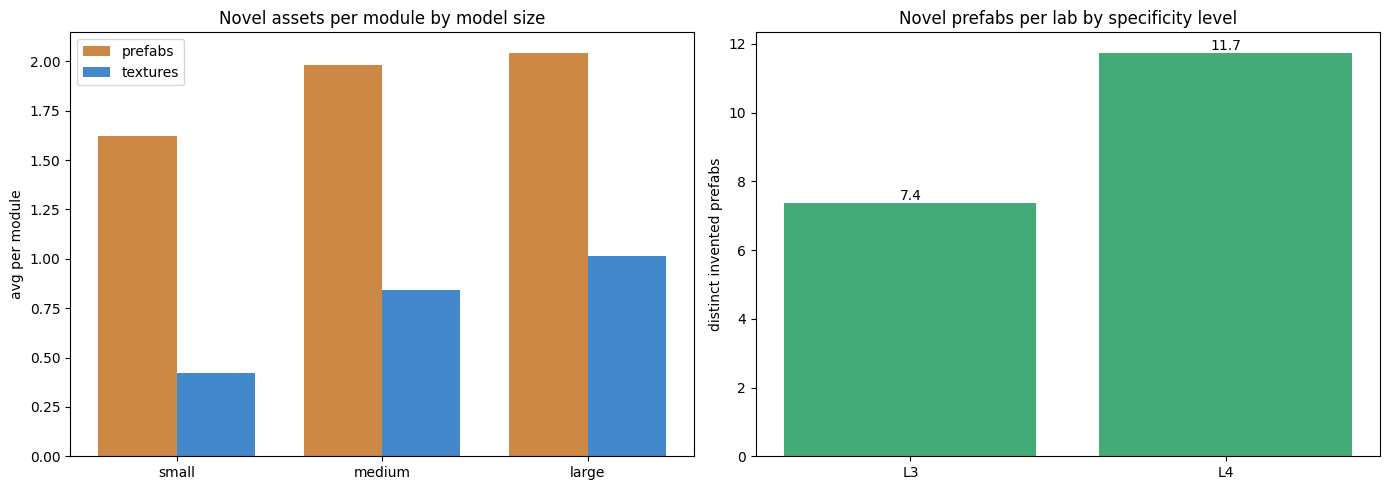

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Novel prefabs & textures per module by model size (json_lab only)
order = ['small', 'medium', 'large']
pm = FULL_JSON.groupby('size').novel_prefabs_per_module.mean().reindex(order)
tm = FULL_JSON.groupby('size').novel_textures_per_module.mean().reindex(order)
x = np.arange(len(order)); w = 0.38
axes[0].bar(x - w/2, pm.values, w, label='prefabs', color='#c84')
axes[0].bar(x + w/2, tm.values, w, label='textures', color='#48c')
axes[0].set_xticks(x); axes[0].set_xticklabels(order)
axes[0].set_title('Novel assets per module by model size')
axes[0].set_ylabel('avg per module'); axes[0].legend()

# Novel prefabs per lab by specificity level (json_lab only)
lv = ['L3', 'L4']
k = FULL_JSON.groupby('level').novel_prefabs.mean().reindex(lv)
axes[1].bar(lv, k.values, color='#4a7')
axes[1].set_title('Novel prefabs per lab by specificity level')
axes[1].set_ylabel('distinct invented prefabs')
for i, v in enumerate(k.values):
    axes[1].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')

plt.tight_layout(); plt.show()

## Failed runs

Failures live only in the `suite_results_*.json` sweeps (a successful run also writes a standalone metrics file; a failed one does not). They split cleanly into two kinds, keyed on whether the run actually reached the model and burned tokens (`had_usage`):

- **Billable failures** — `truncation (max_tokens)` and `schema validation` retries generated real output before failing, so they carry meaningful token / cost / time stats (and are often *more* expensive than a success, because instructor retried).
- **No-op failures** — `404 model-not-found` and config errors never reached the model: 0 tokens, $0, sub-second. They have no relevant statistics and are excluded from the cost/token aggregates below.

In [12]:
# Overview: how common is each failure mode, and is it billable?
ov = FAIL.groupby('fail_mode').agg(
    failed_runs=('model', 'size'),
    billable=('had_usage', 'sum'),
    total_tokens=('total_tokens', 'sum'),
    total_cost_usd=('cost_usd', 'sum'),
    avg_wall_s=('wall_s', 'mean'),
).round({'total_cost_usd': 2, 'avg_wall_s': 1}).sort_values('failed_runs', ascending=False)
print('Failure modes (the "common errors" breakdown):')
display(ov)
wasted = FAIL.cost_usd.sum(); spent = OK.cost_usd.sum()
print(f'Spend on failed runs: ${wasted:.2f}  ({wasted / (wasted + spent):.1%} of total ${wasted + spent:.2f}) — all from billable failures.')

Failure modes (the "common errors" breakdown):


,failed_runs,billable,total_tokens,total_cost_usd,avg_wall_s
fail_mode,,,,,
schema validation,28,28,1790104,1.41,74.8
other,6,6,21450,0.00,39.2


Spend on failed runs: $1.41  (2.7% of total $52.10) — all from billable failures.


### Billable failures — what they cost

Token/cost/time for the failures that actually did work, by model. These are the runs worth attention: real money spent on output that didn't validate or got truncated.

In [13]:
BILL = FAIL[FAIL.had_usage]
by_model = BILL.groupby('display_name').agg(
    failed_runs=('model', 'size'),
    total_tokens=('total_tokens', 'sum'),
    total_cost_usd=('cost_usd', 'sum'),
    avg_wall_s=('wall_s', 'mean'),
    avg_retries=('retries', 'mean'),
).round({'total_cost_usd': 3, 'avg_wall_s': 1, 'avg_retries': 1})
display(by_model.sort_values('total_cost_usd', ascending=False))
print('By level:')
display(BILL.groupby('level').agg(
    failed_runs=('model', 'size'),
    avg_tokens=('total_tokens', 'mean'),
    avg_cost_usd=('cost_usd', 'mean'),
    avg_wall_s=('wall_s', 'mean'),
).round(2))

,failed_runs,total_tokens,total_cost_usd,avg_wall_s,avg_retries
display_name,,,,,
Claude Haiku 4.5,3,293675,0.607,159.4,7.0
Gemini 3.1 Pro,1,111170,0.452,197.0,7.0
Gemini 2.5 Flash Lite,23,1009652,0.169,45.1,4.7
GPT-5.4 Nano,6,362317,0.167,100.8,7.0
Gemini 3.1 Flash Lite,1,34740,0.014,12.6,7.0


By level:


,failed_runs,avg_tokens,avg_cost_usd,avg_wall_s
level,,,,
L3,16,47581.88,0.03,47.87
L4,18,58346.89,0.05,86.94


### No-op failures — no relevant statistics

Listed for completeness; these never billed. (`404` = deprecated/bad model id; `other` = a missing-argument config error.)

In [14]:
NOOP = FAIL[~FAIL.had_usage]
display(NOOP[['display_name', 'level', 'lab_name', 'fail_mode', 'total_tokens', 'cost_usd', 'wall_s']].reset_index(drop=True))

,display_name,level,lab_name,fail_mode,total_tokens,cost_usd,wall_s


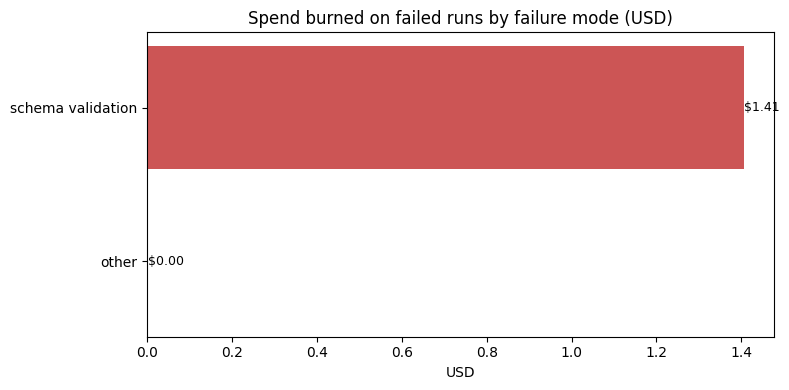

In [15]:
# Cost burned per failure mode (billable only).
fig, ax = plt.subplots(figsize=(8, 4))
fc = BILL.groupby('fail_mode').cost_usd.sum().sort_values()
ax.barh(fc.index, fc.values, color='#c55')
ax.set_title('Spend burned on failed runs by failure mode (USD)')
ax.set_xlabel('USD')
for i, v in enumerate(fc.values):
    ax.annotate(f'${v:.2f}', (v, i), va='center', fontsize=9)
plt.tight_layout(); plt.show()

## Charts

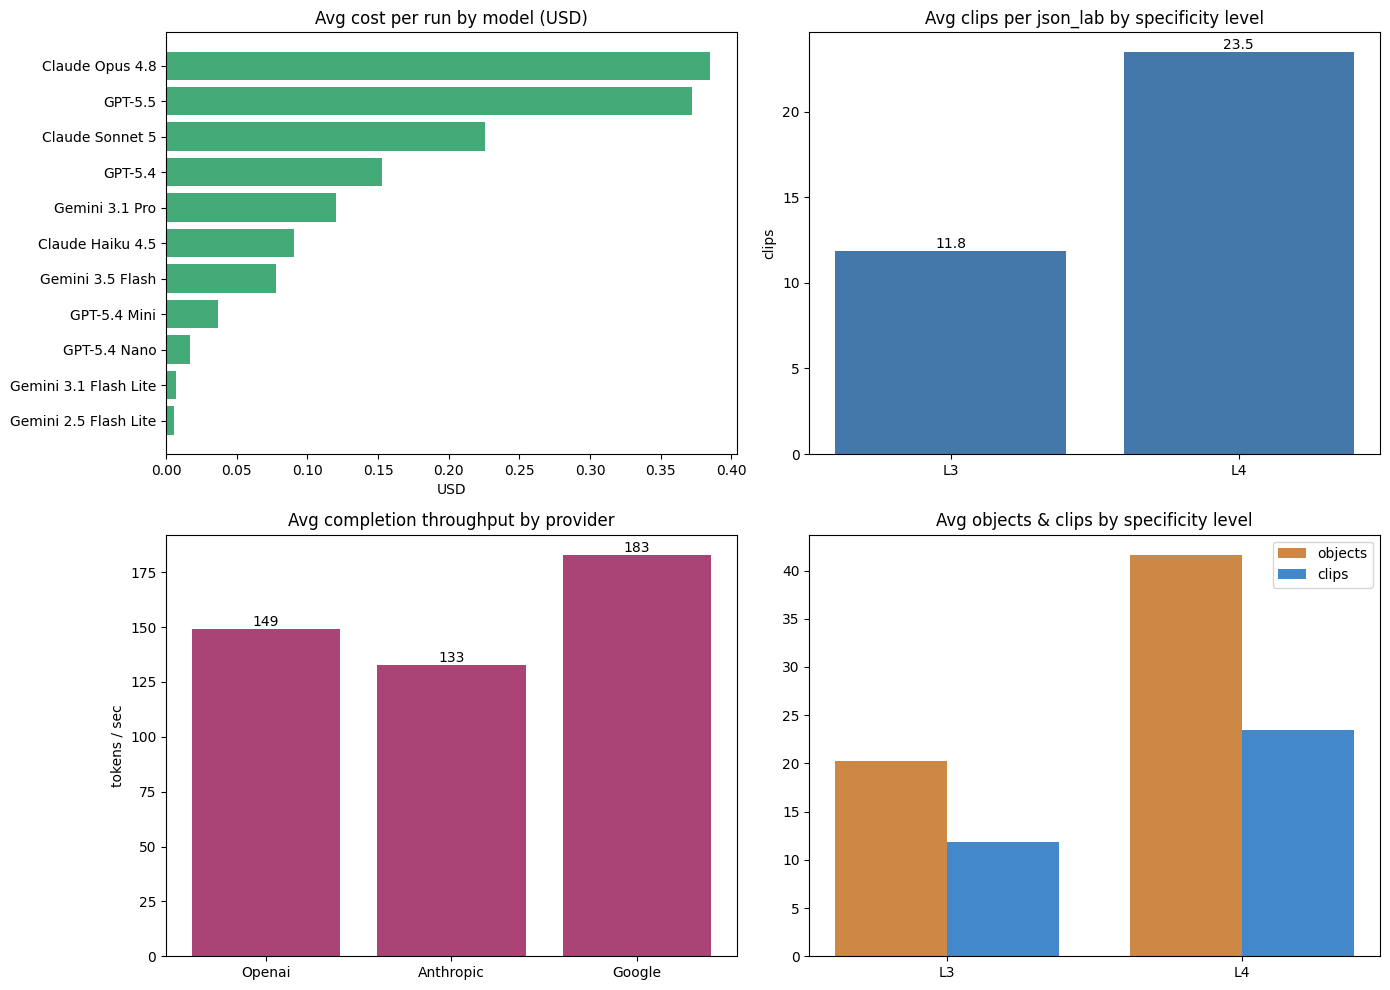

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Avg cost per run by model
c = df.groupby('display_name').cost_usd.mean().sort_values()
axes[0, 0].barh(c.index, c.values, color='#4a7')
axes[0, 0].set_title('Avg cost per run by model (USD)')
axes[0, 0].set_xlabel('USD')

# 2. Avg clips by level (json_lab, L3-L4)
k = FULL_JSON.groupby('level').num_clips.mean().reindex(['L3','L4'])
axes[0, 1].bar(k.index, k.values, color='#47a')
axes[0, 1].set_title('Avg clips per json_lab by specificity level')
axes[0, 1].set_ylabel('clips')
for i, v in enumerate(k.values):
    axes[0, 1].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')

# 3. Avg throughput by provider
s = df.groupby('provider').tokens_per_sec.mean().reindex(PROVIDERS)
axes[1, 0].bar([p.capitalize() for p in s.index], s.values, color='#a47')
axes[1, 0].set_title('Avg completion throughput by provider')
axes[1, 0].set_ylabel('tokens / sec')
for i, v in enumerate(s.values):
    axes[1, 0].annotate(f'{v:.0f}', (i, v), ha='center', va='bottom')

# 4. Avg objects vs clips by level (json_lab)
lv = ['L3', 'L4']
objs = FULL_JSON.groupby('level').num_objects.mean().reindex(lv)
clps = FULL_JSON.groupby('level').num_clips.mean().reindex(lv)
x = np.arange(len(lv)); w = 0.38
axes[1, 1].bar(x - w/2, objs.values, w, label='objects', color='#c84')
axes[1, 1].bar(x + w/2, clps.values, w, label='clips', color='#48c')
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(lv)
axes[1, 1].set_title('Avg objects & clips by specificity level')
axes[1, 1].legend()

plt.tight_layout(); plt.show()

## Notes

- Cost/token figures are the raw provider-reported `cost_usd` / `total_tokens`. Every spec runs free-decode, so there is no Gemini schema-token adjustment (the old `effective_*` columns were retired).
- Structural sections split by **spec_type**: json_lab shape (modules/clips/objects) uses `FULL_JSON`; ARLEM shape (things/places/actions/triggers/POIs) uses `FULL_ARLEM`. A row carries 0 for the columns that don't apply to its spec.
- Structural counts are over **successful** L3–L4 runs only; a model that failed a level contributes no row there.
- Failed-run stats use `had_usage` (`total_tokens > 0`) to separate billable failures from no-op ones; only billable failures enter the cost/token aggregates.
- `num_components` is the count of components created per lab ("new components made"); the per-type breakdown lives in the source metrics' `component_types` if a finer cut is needed.
- Novel-asset counts are computed by re-reading each saved `*_output.json` at load time (no re-running of the sweep); membership in the known moon-lab library is case-insensitive. The invented asset *names* aren't in the CSV but are available per-lab via `lab_metrics.analyze_assets(output_json)` (`novel_prefab_names` / `novel_texture_names`) for qualitative review.